# Multiple Game Analysis

## Loading all the libraries

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from adjustText import *
import pandas as pd
from plotnine import *
import scipy.stats as st
from scipy.interpolate import interp1d
from matplotlib.ticker import MaxNLocator
%matplotlib inline

# Game Set for Analysis

Each game to evaluate should be on a different line in "games".

In [42]:
fileprefix = "../CardStock/output/Taken/"
games = [
    {"game":"Agram","name":"Agram", "player":3},    
    {"game":"AgramPrivate","name":"Agram Private", "player":3},    
    {"game":"AgramTaken","name":"Agram Taken", "player":3},    
]
gameframe = pd.DataFrame.from_dict(games)
gameframe["fileprefix"] = fileprefix
gameframe

,game,name,player,fileprefix
0,Agram,Agram,3,../CardStock/output/Taken/
1,AgramPrivate,Agram Private,3,../CardStock/output/Taken/
2,AgramTaken,Agram Taken,3,../CardStock/output/Taken/


In [ ]:
fileprefix = "../CardStock/output/CardStockVM/"
games = [
    {"game":"Agram","name":"Agram", "player":3},
    {"game":"Blackjack","name":"Blackjack", "player":1},
    {"game":"CrazyEights","name":"Crazy Eights", "player":3},
    {"game":"Cribbage","name":"Cribbage", "player":2},
    {"game":"Cuckoo","name":"Cuckoo", "player":6},
    {"game":"Euchre","name":"Euchre", "player":4},
    {"game":"GoFish","name":"Go Fish", "player":4},
    {"game":"GolfSix","name":"Golf-6", "player":4},
    {"game":"GOPS","name":"Goofspiel", "player":2},
    {"game":"Hearts","name":"Hearts", "player": 4},
    {"game":"Klaverjassen","name":"Klaverjassen", "player":4},
    {"game":"LeducPoker","name":"Leudec Hold'em", "player":2},
    {"game":"Pitch","name":"Pitch", "player":4},
    {"game":"President","name":"President", "player":5},
    {"game":"BlockRummy","name":"Rummy", "player":2},
    {"game":"Scarto","name":"Scarto", "player":3},
    {"game":"Schwimmen","name":"Schwimmen", "player":5},
    {"game":"Scopa","name":"Scopa", "player":2},
    {"game":"Skittgube","name":"Skitgubbe", "player":3},
    {"game":"Sueca","name":"Sueca", "player":4},
    {"game":"Whist","name":"Whist", "player":4},    
]
gameframe = pd.DataFrame.from_dict(games)
gameframe["fileprefix"] = fileprefix
gameframe

In [2]:
fileprefix = "../CardStock/output/"
games = [

    {"game":"ShastaSam","name":"Shasta Sam", "player":2},
    {"game":"CaliforniaJack","name":"California Jack", "player":2},
    {"game":"Caterpillar","name":"Caterpillar", "player":2},
    {"game":"Coloretto","name":"Coloretto", "player":4},
    {"game":"Comet","name":"Comet", "player":2},
#    {"game":"Coup","name":"Coup", "player":4},
    {"game":"Escoba","name":"Escoba", "player":2},
    {"game":"LostCities","name":"Lost Cities", "player":2},
    {"game":"LAMA","name":"LAMA", "player":4},
    {"game":"NoThanks","name":"No Thanks", "player":4},
    {"game":"PageOne","name":"Page One", "player":3},
    {"game":"Knaves","name":"Knaves", "player":3},
    {"game":"NinetyEight","name":"Ninety Eight", "player":4},
    {"game":"SaneEights","name":"Sane Eights", "player":4},
    {"game":"SheepsheadPicker","name":"Sheepshead", "player":5},
    {"game":"Simon'sCat","name":"Simon's Cat", "player":4},
    {"game":"SpiteMalice","name":"Spite and Malice", "player":2},
    {"game":"TurnTheTide","name":"Turn The Tide", "player":3},
    {"game":"BottleImp","name":"The Bottle Imp", "player":3},
    {"game":"Pairs","name":"Pairs", "player":3},
    {"game":"PairsPort","name":"Pairs Port", "player":4},
    {"game":"Clocktowers","name":"Clocktowers", "player":2},
    {"game":"Briscola","name":"Briscola", "player":2},
    {"game":"Trifle","name":"Trifle", "player":2},
    {"game":"SixNimmt","name":"6 Nimmt", "player":5},
    {"game":"FoxInTheForest","name":"The Fox in the Forest", "player":2},
    {"game":"GermanWhist","name":"German Whist", "player":2},
    {"game":"Slobberhannes","name":"Slobberhannes", "player":4},
    {"game":"Polignac","name":"Polignac", "player":4},
    {"game":"StealingBundles","name":"Stealing Bundles", "player":2},
    {"game":"DuckSoup","name":"Duck Soup", "player":2},
    {"game":"Pico","name":"Pico", "player":2},
    {"game":"PicoTwo","name":"Pico 2", "player":2},
#    {"game":"Trio","name":"Trio", "player":4},
    {"game":"Diamant","name":"Diamant", "player":8},
    {"game":"LoveLetter","name":"Love Letter", "player":4},
    {"game":"Poison","name":"Poison", "player":5},
#    {"game":"Escalation","name":"Escalation!", "player":4},
#    {"game":"GoldRush","name":"Gold Rush!", "player":3},
    {"game":"AbandonAllArtichokes","name":"Abandon All Artichokes", "player":2},
    {"game":"Nanuk","name":"Nanuk", "player":6},
    {"game":"SushiGo","name":"Sushi Go!", "player":4},

]
gameframe = pd.DataFrame.from_dict(games)
gameframe["fileprefix"] = fileprefix
#gameframe = pd.concat([gameframe, gameframe2])
gameframe

,game,name,player,fileprefix
0,ShastaSam,Shasta Sam,2,../CardStock/output/
1,CaliforniaJack,California Jack,2,../CardStock/output/
2,Caterpillar,Caterpillar,2,../CardStock/output/
3,Coloretto,Coloretto,4,../CardStock/output/
4,Comet,Comet,2,../CardStock/output/
5,Escoba,Escoba,2,../CardStock/output/
6,LostCities,Lost Cities,2,../CardStock/output/
7,LAMA,LAMA,4,../CardStock/output/
8,NoThanks,No Thanks,4,../CardStock/output/
9,PageOne,Page One,3,../CardStock/output/


# Branching Factor

This first gather data into a dataframe, which will enable us to draw graphs to show how the branching factor of the game changes over time.

This data is from games with all **random** players.

In [43]:
first = True
for index, row in gameframe.iterrows():
    gf = pd.read_csv(row["fileprefix"] + row["game"] + "/" + str(row["player"]) + "/" + "R" * row["player"] + "/choice.csv")
    print(row["game"])
    gf["game"] = row["game"]
    gf["name"] = row["name"]
    if first:
        choiceframe = gf
        first = False
    else:
        choiceframe = pd.concat([choiceframe, gf])
    gf = pd.read_csv(row["fileprefix"] + row["game"] + "/" + str(row["player"]) + "/" + "M" + "R" * (row["player"] - 1) + "/choice.csv")
    gf["game"] = row["game"]
    gf["name"] = row["name"]
    choiceframe = pd.concat([choiceframe, gf])

Agram
AgramPrivate
AgramTaken


In [44]:
choiceframe

,game,numPlayers,ai,imperfect,samples,tests,run,move,player,choices,choice,time,name
0,Agram,3,RRRR,PRIVATE,10,1000,1,1,1,6,4,0,Agram
1,Agram,3,RRRR,PRIVATE,10,1000,1,2,2,4,3,0,Agram
2,Agram,3,RRRR,PRIVATE,10,1000,1,3,3,6,6,0,Agram
3,Agram,3,RRRR,PRIVATE,10,1000,1,4,1,5,2,0,Agram
4,Agram,3,RRRR,PRIVATE,10,1000,1,5,2,1,1,0,Agram
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1795,AgramTaken,3,MRR,TAKEN,10,1000,100,14,3,1,1,0,Agram Taken
1796,AgramTaken,3,MRR,TAKEN,10,1000,100,15,1,2,1,0,Agram Taken
1797,AgramTaken,3,MRR,TAKEN,10,1000,100,16,2,1,1,69,Agram Taken
1798,AgramTaken,3,MRR,TAKEN,10,1000,100,17,3,1,1,0,Agram Taken


## Convergence

The **Convergence** is a summary, the average slope of all the runs for a game, squished into a number between 0 and 1. 0.5 means a flat horizontal line, 0 is straight up, and 1 is straight down.

In [45]:
cseq = []
cf = choiceframe[choiceframe["ai"].str.startswith("R")]
for index, row in gameframe.iterrows():
    print(row["game"])
    cf2 = cf[(cf["game"]==row["game"])]
    convergence = 0
    count = 0
    for i in range(100):
        tempf = cf2[(cf2["run"]==i)]
        if len(tempf) > 1:
            slope, intercept, r_value, p_value, std_error = st.linregress(tempf["move"], tempf["choices"])
            convergence += (1 - (slope / 2 + 0.5))
            count += 1
    cseq.append(convergence / count)

Agram
AgramPrivate
AgramTaken


In [46]:
gameframe["convergence"] = cseq
gameframe

,game,name,player,fileprefix,convergence
0,Agram,Agram,3,../CardStock/output/Taken/,0.595209
1,AgramPrivate,Agram Private,3,../CardStock/output/Taken/,0.595209
2,AgramTaken,Agram Taken,3,../CardStock/output/Taken/,0.595209


## Plotting all games

This plot shows the branching factors over all of the games in the testbed for random players.

In [17]:
game = "WhistPrivateHidden"
choiceframe["player"] = choiceframe["player"].astype(str)
cplot = (ggplot(choiceframe[(choiceframe["ai"].str.startswith("R")) & (choiceframe["game"] == game)], aes("move", "choices", color="player"))
 + geom_jitter(size=0.05, alpha=0.9)
 + geom_smooth(method="loess", color="steelblue")
 + aes(ymin=0)
 + theme_minimal(base_family="Futura", base_size=11) 
 + theme(legend_position='none', figure_size=(6, 6))
 + theme(
        #plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        panel_spacing=0.03,
    )
 + labs(x='Decision Point', y='Branching Factor', title=gameframe[gameframe["game"]==game]["name"].item())
 + scale_colour_manual(values = ("red", "goldenrod", "limegreen", "cyan", "blue", "violet"))
)
cplot.save("Choices"+game+".png")
cplot.show()

ValueError: can only convert an array of size 1 to a Python scalar

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 8 x 10 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ChoicesRandom.png


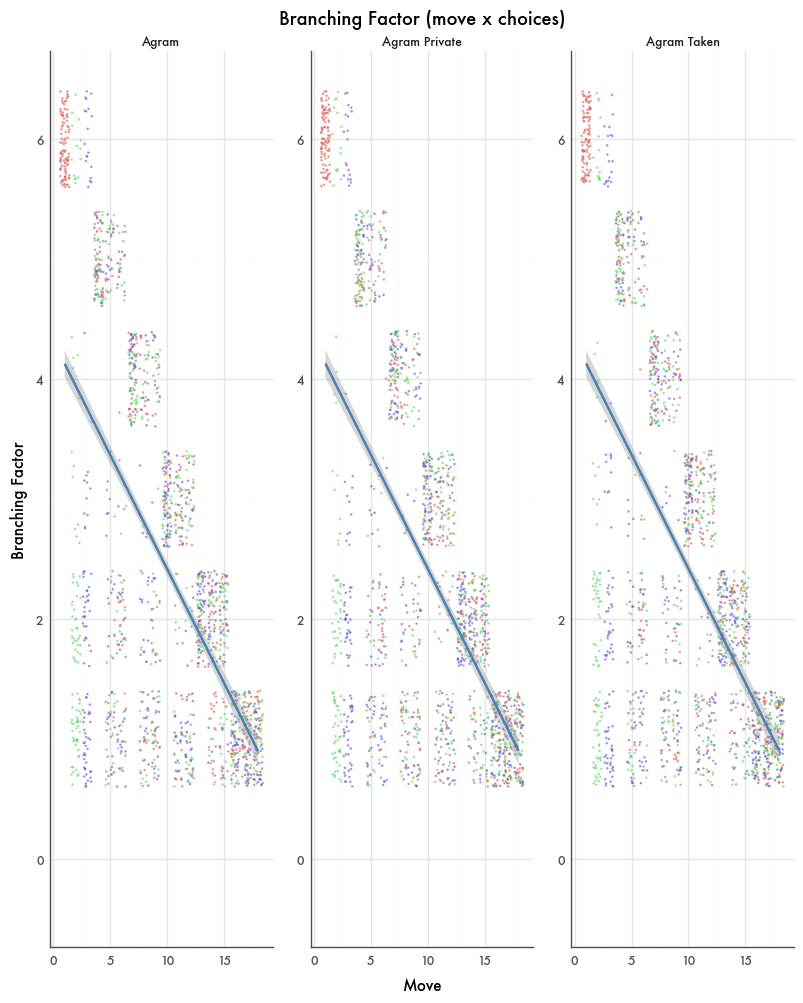

In [47]:
choiceframe["player"] = choiceframe["player"].astype(str)
cplot = (ggplot(choiceframe[choiceframe["ai"].str.startswith("R")], aes("move", "choices", color="player"))
 + geom_jitter(size=0.05, alpha=0.5)
 + geom_smooth(method="lm", color="steelblue")
 + facet_wrap("name", scales = "free", ncol = 5)
 + aes(ymin=0)
 + theme_minimal(base_family="Futura", base_size=11) 
 + theme(legend_position='none', figure_size=(8, 10))
 + theme(
#        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
 #       axis_title=element_blank(),
        panel_spacing=0.03,
     
    )
 + labs(x='Move', y='Branching Factor', title="Branching Factor (move x choices)")
)
cplot.save("ChoicesRandom.png")
cplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: AllChoicesRandom.png


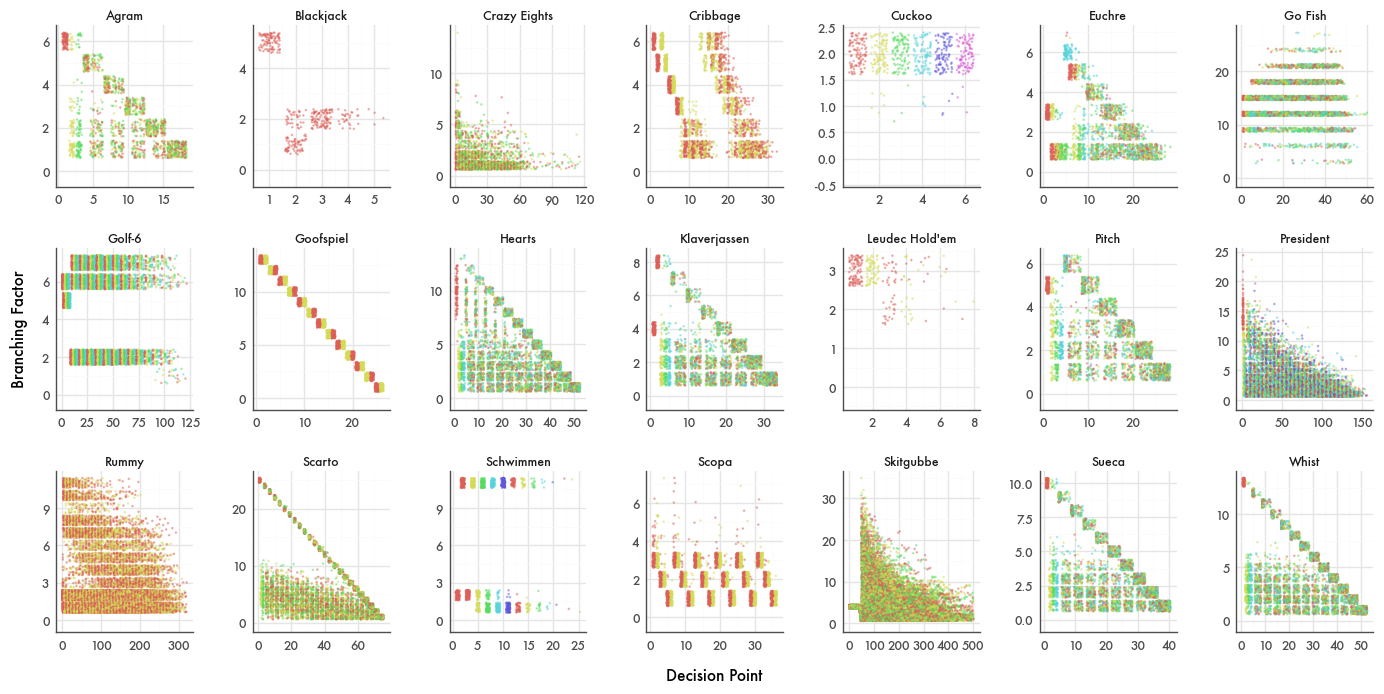

In [8]:
choiceframe["player"] = choiceframe["player"].astype(str)
cplot = (ggplot(choiceframe[choiceframe["ai"].str.startswith("R")], aes("move", "choices", color="player"))
 + geom_jitter(size=0.05, alpha=0.4)
 + facet_wrap("name", scales = "free", ncol = 7)
 + aes(ymin=0)
 + theme_minimal(base_family="Futura", base_size=11) 
 + theme(legend_position='none', figure_size=(14, 7))
 + theme(
#        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        #axis_title=element_blank(),
        panel_spacing=0.02,
     
    )
 + labs(x='Decision Point', y='Branching Factor')

)
cplot.save("AllChoicesRandom.png")
cplot.show()

This plot is the branching factor for the PIPMC players

In [8]:
choiceframe["player"] = choiceframe["player"].astype(str)
cplot = (ggplot(choiceframe[choiceframe["ai"].str.startswith("P")], aes("move", "choices", color="player"))
 + geom_jitter(size=0.05, alpha=0.5)
 + geom_smooth(method="loess", color="steelblue")
 + facet_wrap("game", scales = "free", ncol = 7)
 + aes(ymin=0)
 + theme_minimal(base_family="Futura", base_size=11) 
 + theme(legend_position='none', figure_size=(14, 14))
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + labs(x='Move', y='Branching Factor', title="Branching Factor (move x choices)")
)
cplot.save("ChoicesPIPMC.png")
cplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 14 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ChoicesPIPMC.png


ValueError: b'There are other near singularities as well. 1\n'

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 8 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ChoicesMCTS.png


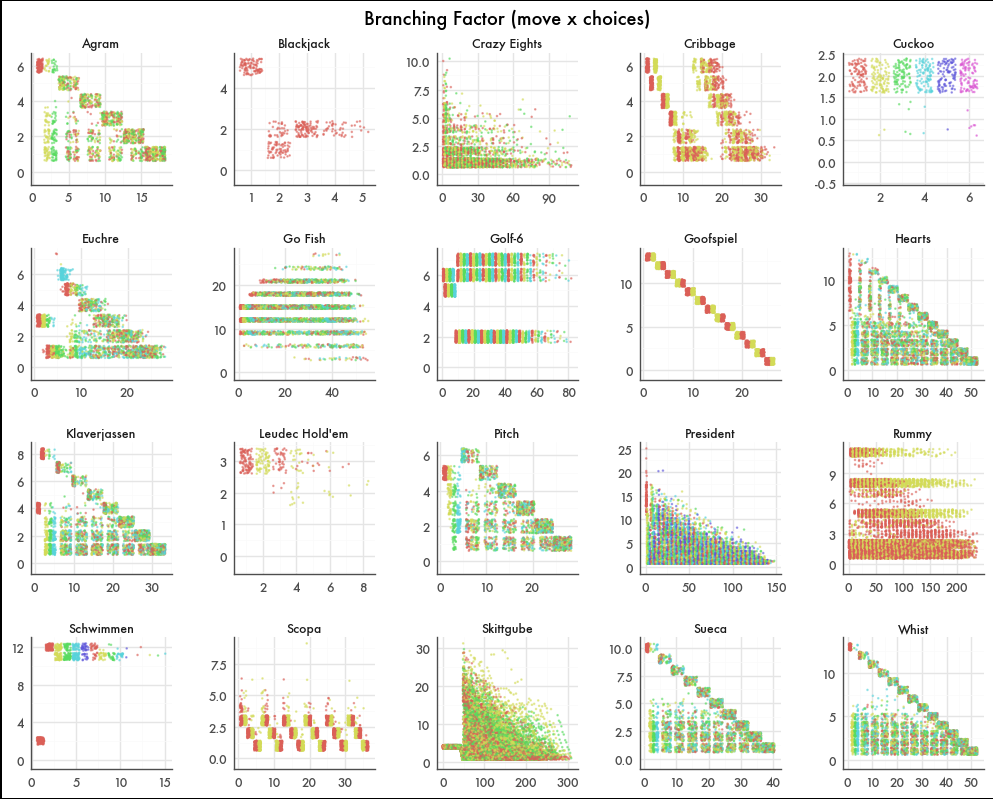

In [30]:
choiceframe["player"] = choiceframe["player"].astype(str)
cplot = (ggplot(choiceframe[choiceframe["ai"].str.startswith("M")], aes("move", "choices", color="player"))
 + geom_jitter(size=0.05, alpha=0.5)
 + facet_wrap("name", scales = "free", ncol = 5)
 + aes(ymin=0)
 + theme_minimal(base_family="Futura", base_size=11) 
 + theme(legend_position='none', figure_size=(10, 8))
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + labs(x='Move', y='Branching Factor', title="Branching Factor (move x choices)")
)
cplot.save("ChoicesMCTS.png")
cplot.show()

And one plot that shows them all.

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 20 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Choices.png


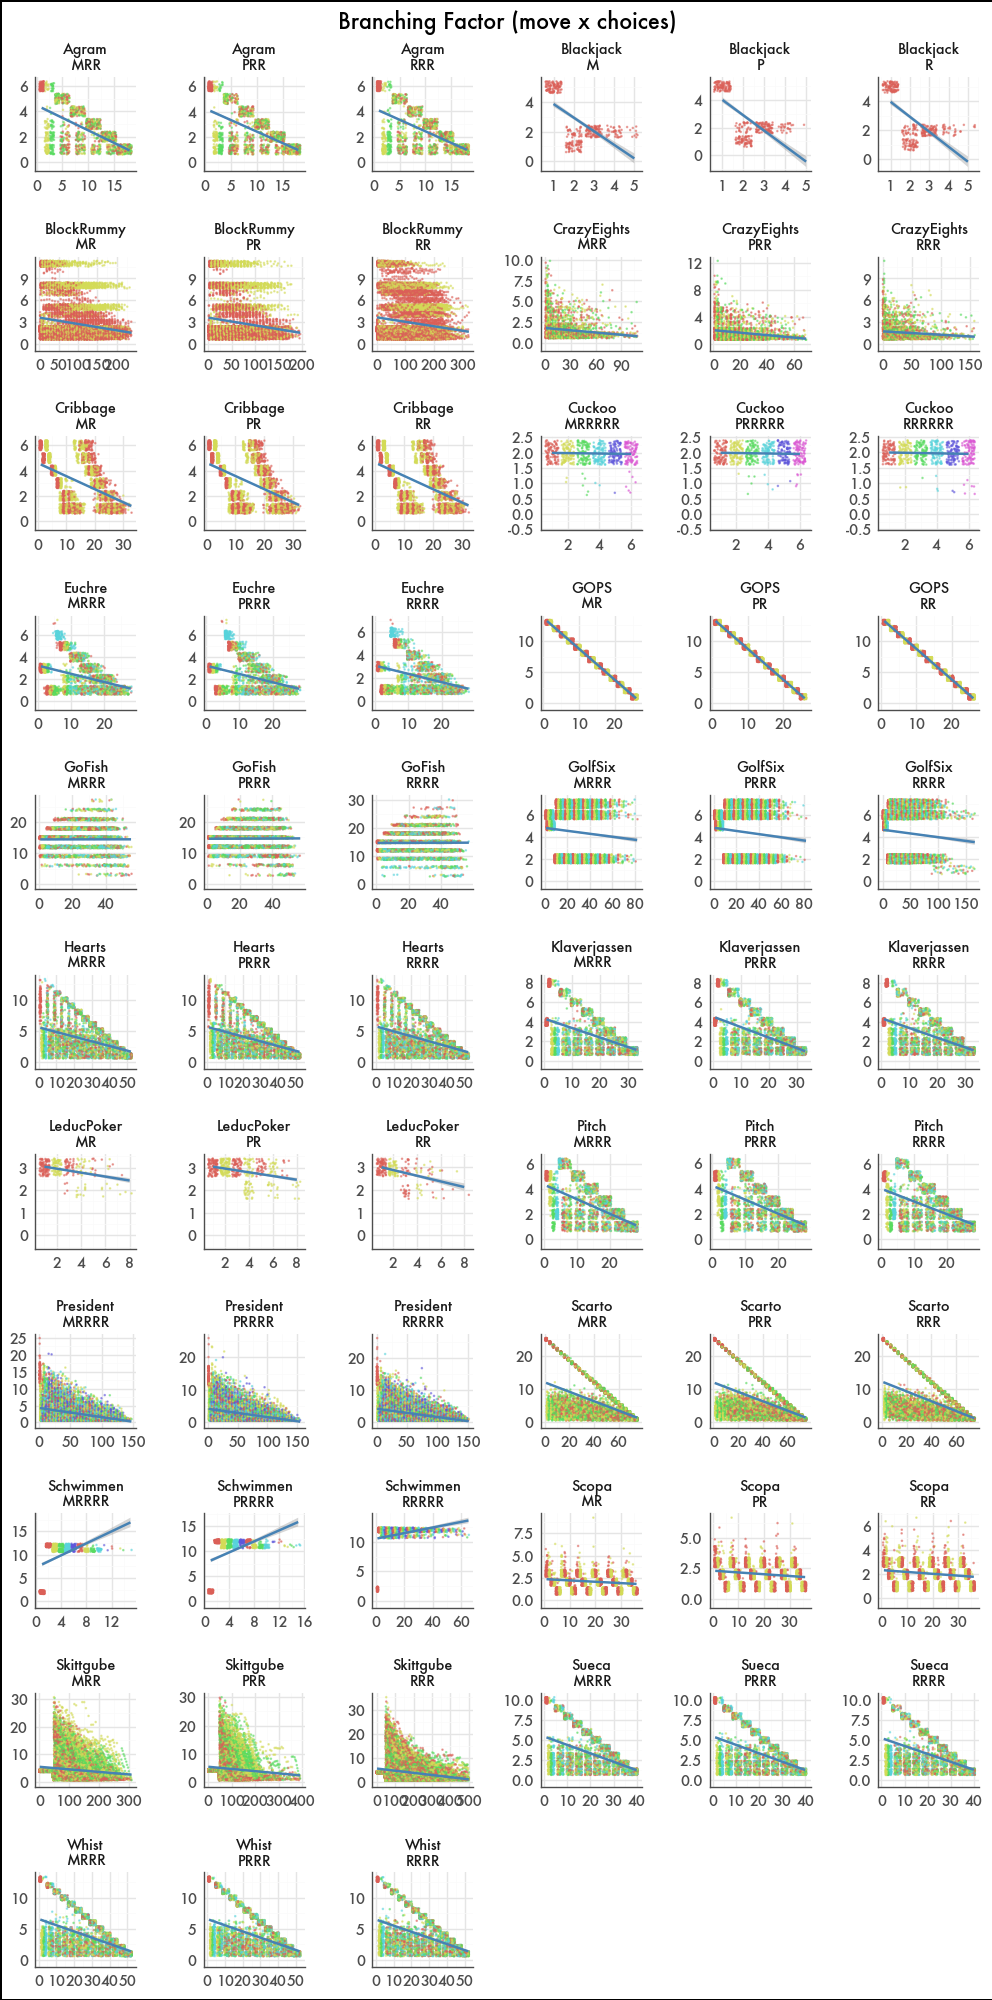

In [57]:
choiceframe["player"] = choiceframe["player"].astype(str)
cplot = (ggplot(choiceframe, aes("move", "choices", color="player"))
 + geom_jitter(size=0.05, alpha=0.5)
 + geom_smooth(method="lm", color="steelblue")
 + facet_wrap(["game", "ai"], scales = "free", ncol = 6)
 + aes(ymin=0)
 + theme_minimal(base_family="Futura", base_size=13) 
 + theme(legend_position='none', figure_size=(10, 20))
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + labs(x='Move', y='Branching Factor', title="Branching Factor (move x choices)")
)
cplot.save("Choices.png")
cplot.show()

# Game Length

We can calculate the average game length, by finding the max value for the move column on each run, then averaging

In [48]:
choiceframe[['game', 'run', 'move']][choiceframe["ai"].str.startswith("R")].groupby(['game', 'run'], as_index=False)['move'].max().groupby(['game'], as_index=False).mean()

,game,run,move
0,Agram,50.5,18.0
1,AgramPrivate,50.5,18.0
2,AgramTaken,50.5,18.0


In [49]:
lengthframe = choiceframe[['name', 'run', 'move']][choiceframe["ai"].str.startswith("M")].groupby(['name', 'run'], as_index=False)['move'].max()
lengthframe

,name,run,move
0,Agram,1,18
1,Agram,2,18
2,Agram,3,18
3,Agram,4,18
4,Agram,5,18
...,...,...,...
295,Agram Taken,96,18
296,Agram Taken,97,18
297,Agram Taken,98,18
298,Agram Taken,99,18


/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 5 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: LengthM.png


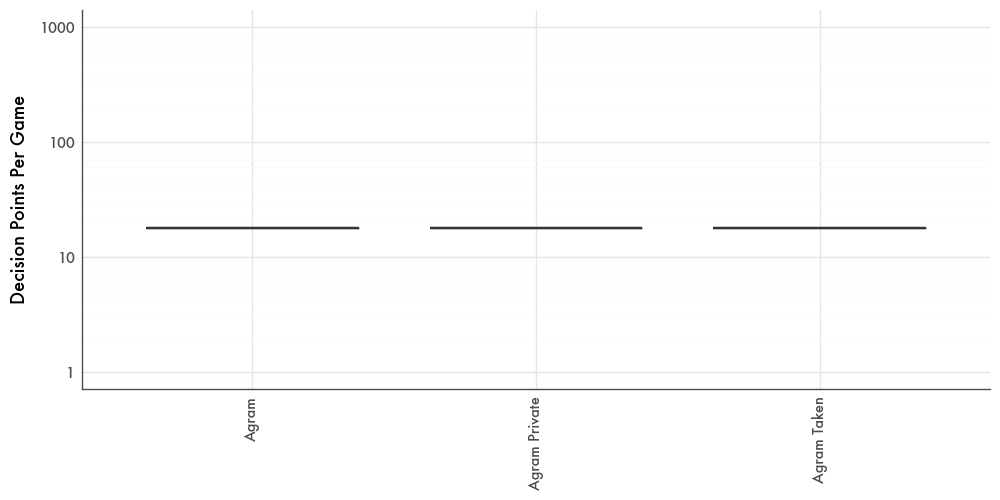

In [50]:
lplot = (ggplot(lengthframe, aes("name", "move"))
 + geom_boxplot()
 + theme_minimal(base_family="Futura", base_size=13) 
 + theme(legend_position='none', figure_size=(10, 5))
 + theme(
        axis_text_x=element_text(rotation=90),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        panel_spacing=0.03,
    )
 + scale_y_log10(limits=(1, 1000))        
 + labs(y="Decision Points Per Game", x="")
)
lplot.save("LengthM.png")
lplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 5 x 5 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: LengthCrazy Eights.png


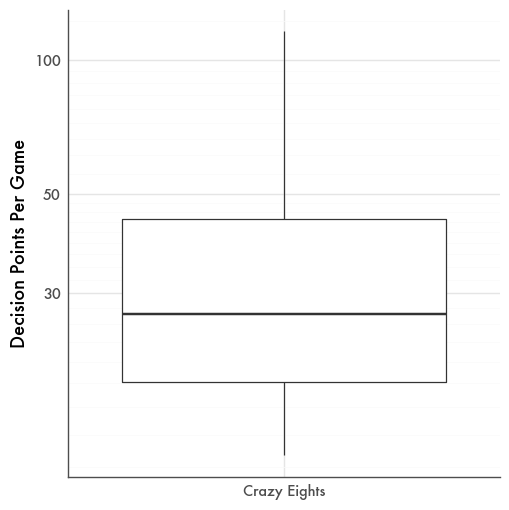

In [34]:
game = "Crazy Eights"
lplot = (ggplot(lengthframe[lengthframe["name"]==game], aes("name", "move"))
 + geom_boxplot()
 + theme_minimal(base_family="Futura", base_size=13) 
 + theme(legend_position='none', figure_size=(5, 5))
 + theme(
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        panel_spacing=0.03,
    )
 + scale_y_log10() 
 + labs(y="Decision Points Per Game", x="")
)
lplot.save("Length"+ game +".png")
lplot.show()

In [12]:
lengthf = choiceframe[['game', 'run', 'move']][choiceframe["ai"].str.startswith("R")].groupby(['game', 'run'], as_index=False)['move'].max().groupby(['game'], as_index=False).mean()[['game', 'move']]
gameframe = gameframe.merge(lengthf, on='game', how='left')

In [38]:
gameframe

,game,name,player,fileprefix,convergence,fairness,order,gain,MCTS
0,WhistHiddenPrivate,Whist Private,4,../CardStock/output/Valet/,0.549168,0.68,0.466667,0.11,0.60
1,WhistHiddenTaken,Whist Taken,4,../CardStock/output/Valet/,0.549168,0.68,0.400000,0.06,0.55


# Results

For random games, we want to look at the distribution of win/loss percentages across the players.

In [51]:
first = True
for index, row in gameframe.iterrows():
    print(row["game"])
    gf = pd.read_csv(row["fileprefix"] + row["game"] + "/" + str(row["player"]) + "/" + "R" * row["player"] + "/results.csv")
    if row["game"] == "Schwimmen":
        gf["score"] = gf["score"] / 2.0
    gf["game"] = row["game"]
    gf["name"] = row["name"]
    gf["ai"] = "Random"
    if first:
        resultsframe = gf
        first = False
    else:
        resultsframe = pd.concat([resultsframe, gf])
    gf = pd.read_csv(row["fileprefix"] + row["game"] + "/" + str(row["player"]) + "/" + "M" + "R" * (row["player"] - 1) + "/results.csv")
    if row["game"] == "Schwimmen":
        gf["score"] = gf["score"] / 2.0
    gf["game"] = row["game"]
    gf["name"] = row["name"]
    gf["ai"] = "MCTS"
    resultsframe = pd.concat([resultsframe, gf])
#    gf = pd.read_csv(row["fileprefix"] + row["game"] + "/" + str(row["player"]) + "/" + "P" + "R" * (row["player"] - 1) + "/results.csv")
#    if row["game"] == "Schwimmen":
#        gf["score"] = gf["score"] / 2.0
#    gf["game"] = row["game"]
#    gf["name"] = row["name"]
#    gf["ai"] = "PIPMC"
#    resultsframe = pd.concat([resultsframe, gf])

resultsframe["player"] = resultsframe["player"].astype(str)
resultsframe["rank"] = resultsframe["rank"].astype(str)
resultsframe

Agram
AgramPrivate
AgramTaken


,game,numPlayers,ai,imperfect,samples,tests,run,player,score,rank,time,name
0,Agram,3,Random,PRIVATE,10,1000,1,1,0,2,21.2181,Agram
1,Agram,3,Random,PRIVATE,10,1000,1,2,0,2,21.2181,Agram
2,Agram,3,Random,PRIVATE,10,1000,1,3,1,1,21.2181,Agram
3,Agram,3,Random,PRIVATE,10,1000,2,1,1,1,2.6936,Agram
4,Agram,3,Random,PRIVATE,10,1000,2,2,0,2,2.6936,Agram
...,...,...,...,...,...,...,...,...,...,...,...,...
295,AgramTaken,3,MCTS,TAKEN,10,1000,99,2,0,2,3753.3301,Agram Taken
296,AgramTaken,3,MCTS,TAKEN,10,1000,99,3,1,1,3753.3301,Agram Taken
297,AgramTaken,3,MCTS,TAKEN,10,1000,100,1,0,2,5292.0436,Agram Taken
298,AgramTaken,3,MCTS,TAKEN,10,1000,100,2,1,1,5292.0436,Agram Taken


# Timing

In [52]:
pgames = resultsframe[['name', 'run', 'ai', 'time']]
what = pgames.groupby(['name', 'run', 'ai'], as_index=False)['time'].max()
timef = what.groupby(['name', 'ai'], as_index=False).median()[['name', 'time', 'ai']]
timef

,name,time,ai
0,Agram,4855.52860,MCTS
1,Agram,2.76955,Random
2,Agram Private,5085.16260,MCTS
3,Agram Private,2.76955,Random
4,Agram Taken,4952.51165,MCTS
5,Agram Taken,2.76955,Random


/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 8 x 5 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Time.png


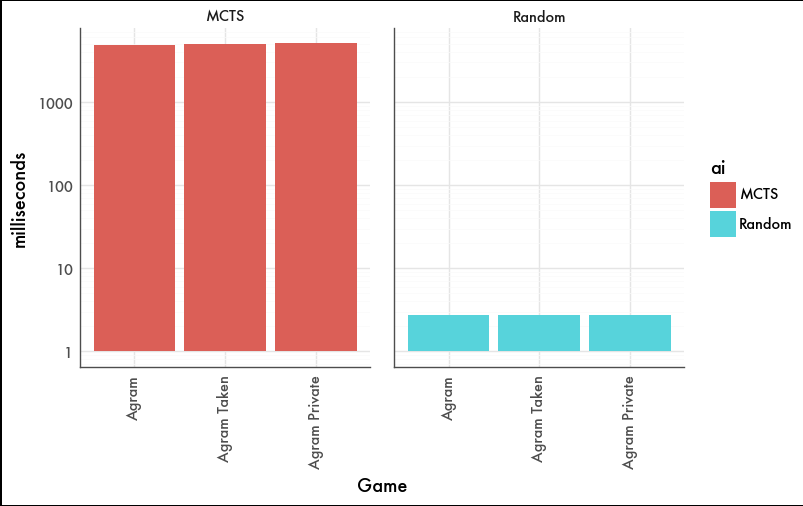

In [53]:
rplot = (ggplot(timef, aes("reorder(name, time)", "time", fill="ai"))
 + geom_bar(position="dodge", stat="identity")
 + facet_wrap(["ai"])
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(figure_size=(8, 5))
 + theme(
        axis_text_x=element_text(rotation=90),
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        panel_spacing=0.03,
    )
 + labs(x='Game', y='milliseconds')
 + scale_y_log10()
)
rplot.save("Time.png")
rplot.show()

In [54]:
rf2 = resultsframe.groupby(['name', 'player', 'rank', 'ai'], as_index=False).count()
rf3 = rf2[(rf2["player"]=="1") & (rf2["rank"] == "1")][["name", "ai", "run"]]
rf3["run"] = rf3["run"] / 100
rf4 = rf3.pivot(index='name', columns='ai')
rf4 = rf4["run"].reset_index()
rf4.columns.name=None
rf5 = rf4.merge(gameframe, on='name', how='left')
rf5

,name,MCTS,Random,game,player,fileprefix,convergence
0,Agram,0.52,0.3,Agram,3,../CardStock/output/Taken/,0.595209
1,Agram Private,0.55,0.3,AgramPrivate,3,../CardStock/output/Taken/,0.595209
2,Agram Taken,0.61,0.3,AgramTaken,3,../CardStock/output/Taken/,0.595209


In [55]:
def fairness(wp, np):
    if np == 1:
        return 1
    if wp < 1 / np:
        return wp * np
    else:
        return (np - np * wp) / (np - 1)
rf5["fairness"] = rf5.apply(lambda x: fairness(x.Random, x.player), axis=1)
def order(aiwp, np):
    if np == 1:
        return 1
    ewp = 1 / np
    return (aiwp - ewp) / (1 - ewp)
rf5["order"] = rf5.apply(lambda x: order(x.MCTS, x.player), axis=1)
rf5["gain"] = rf5.apply(lambda x: x.MCTS - x.Random, axis=1)
rf5

,name,MCTS,Random,game,player,fileprefix,convergence,fairness,order,gain
0,Agram,0.52,0.3,Agram,3,../CardStock/output/Taken/,0.595209,0.9,0.280,0.22
1,Agram Private,0.55,0.3,AgramPrivate,3,../CardStock/output/Taken/,0.595209,0.9,0.325,0.25
2,Agram Taken,0.61,0.3,AgramTaken,3,../CardStock/output/Taken/,0.595209,0.9,0.415,0.31


In [56]:
gameframe = gameframe.merge(rf5[["name", "fairness", "order", "gain", "MCTS"]], on="name", how="left")

In [57]:
gameframe

,game,name,player,fileprefix,convergence,fairness,order,gain,MCTS
0,Agram,Agram,3,../CardStock/output/Taken/,0.595209,0.9,0.280,0.22,0.52
1,AgramPrivate,Agram Private,3,../CardStock/output/Taken/,0.595209,0.9,0.325,0.25,0.55
2,AgramTaken,Agram Taken,3,../CardStock/output/Taken/,0.595209,0.9,0.415,0.31,0.61


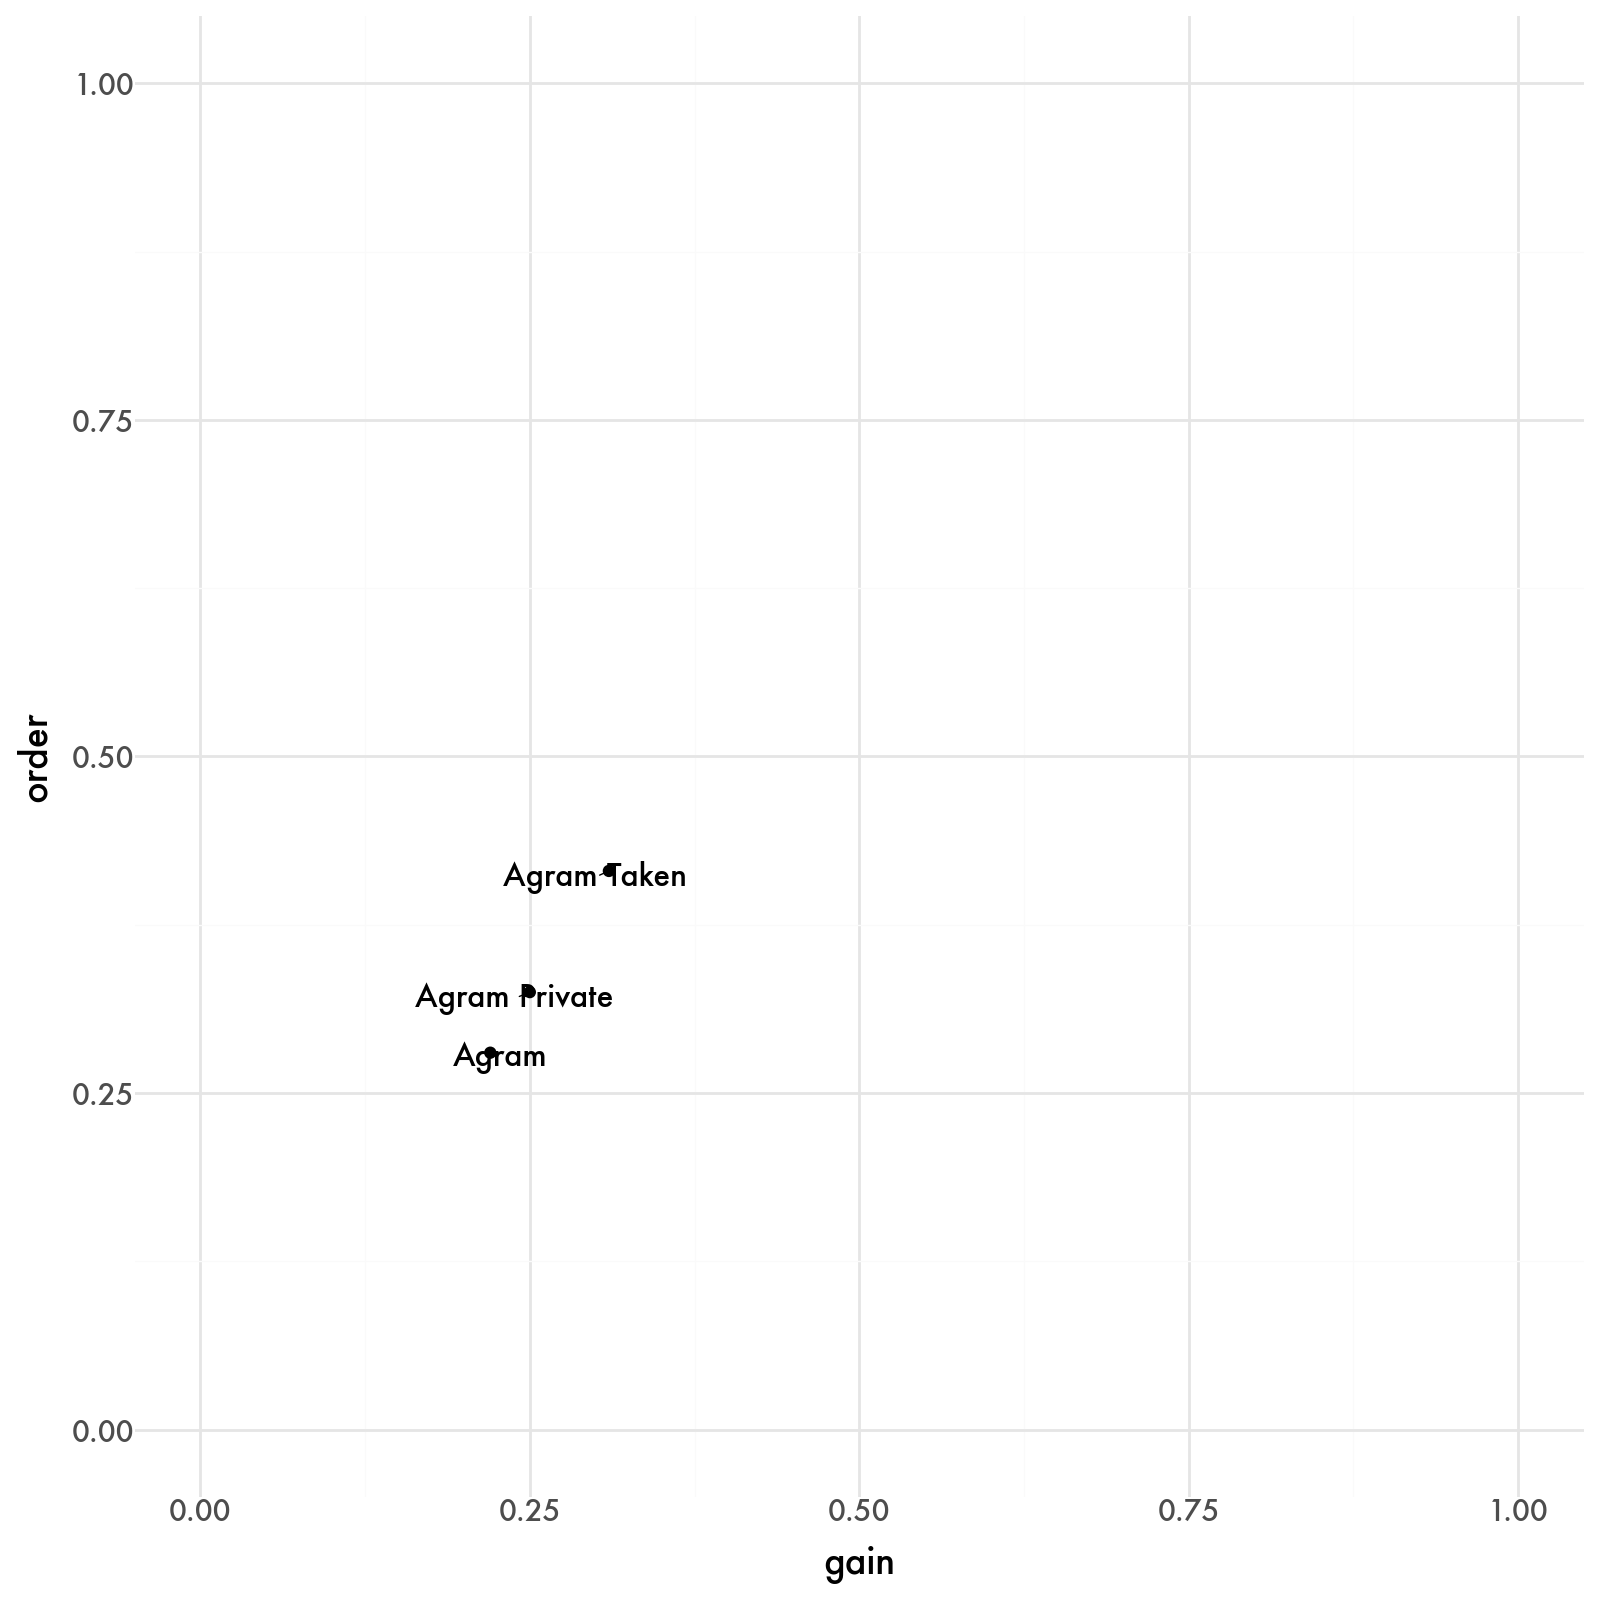

In [58]:
(ggplot(gameframe, aes("gain", "order", label="name"))
 + geom_point()
 + xlim(0, 1)
 + ylim(0, 1)
 + geom_text(adjust_text={"arrowprops": {"arrowstyle": "-"}})
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(figure_size=(8, 8))
)

In [59]:
rf6 = rf3.merge(gameframe[["game", "name", "gain", "player"]], on='name', how='left')
rf6.sort_values(by=['gain'])

,name,ai,run,game,gain,player
0,Agram,MCTS,0.52,Agram,0.22,3
1,Agram,Random,0.30,Agram,0.22,3
2,Agram Private,MCTS,0.55,AgramPrivate,0.25,3
3,Agram Private,Random,0.30,AgramPrivate,0.25,3
4,Agram Taken,MCTS,0.61,AgramTaken,0.31,3
5,Agram Taken,Random,0.30,AgramTaken,0.31,3


/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 5 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Ranks.png


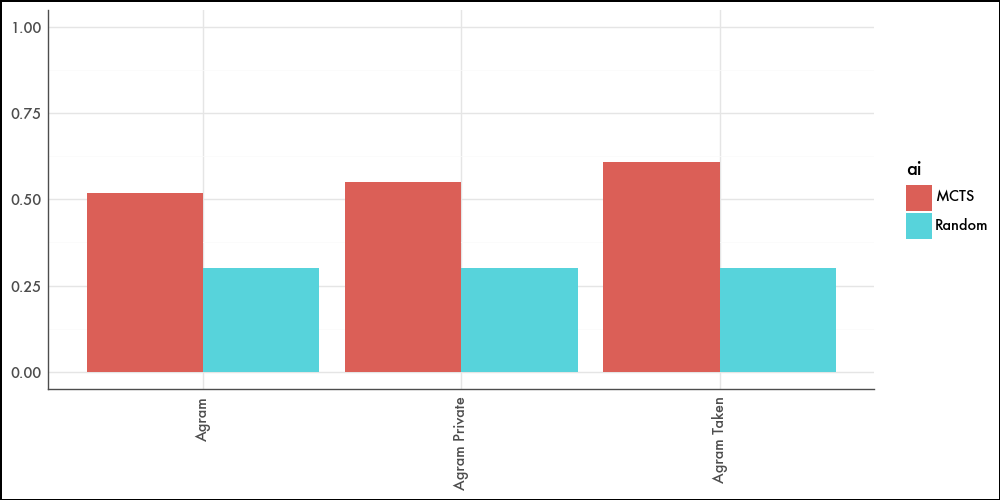

In [60]:
rplot = (ggplot(rf6, aes('reorder(name, gain)', "run", fill="ai"))
 + geom_bar(position="dodge", stat="identity")
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(figure_size=(10, 5))
 + theme(
        axis_text_x=element_text(rotation=90),
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + ylim(0, 1)
 + labs(x='player', y='rank')
)
rplot.save("Ranks.png")
rplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 14 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: AIBarRanks.png


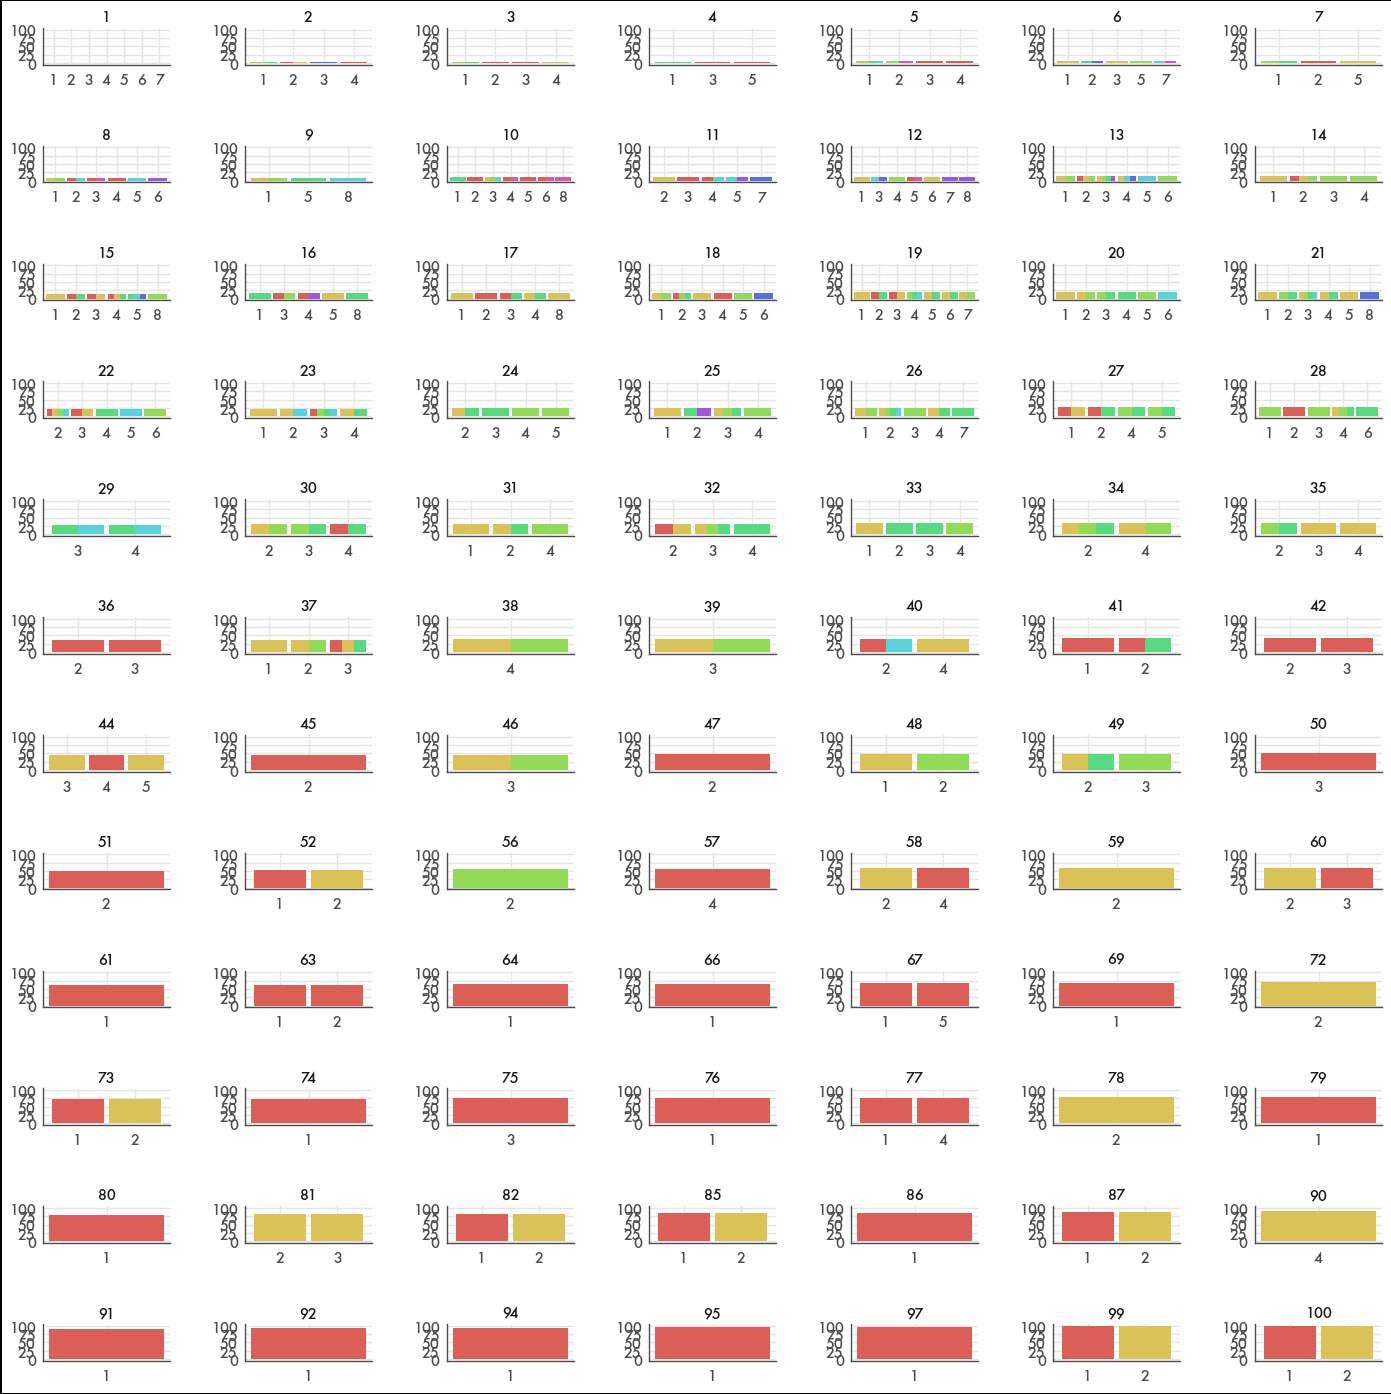

In [23]:
rplot = (ggplot(rf2[rf2["ai"]=="PIPMC"], aes("player", "run", fill="rank"))
 + geom_bar(position="dodge", stat="identity")
 + facet_wrap("game", scales = "free", ncol=7)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(14, 14))
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + ylim(0, 100)
 + labs(x='player', y='rank')
)
rplot.save("AIBarRanks.png")
rplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 8 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: RandomScores.png


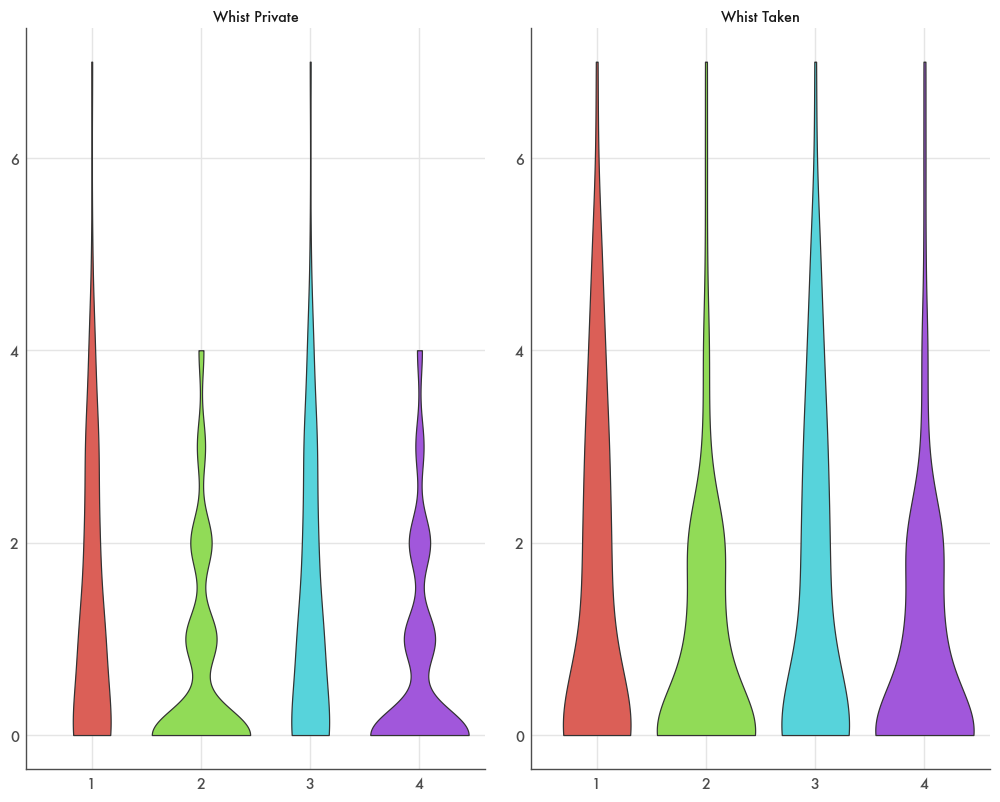

In [36]:
splot = (ggplot(resultsframe[resultsframe["ai"].str.startswith("M")], aes("player", "score", fill="player"))
 + geom_violin()
 + facet_wrap("name", scales = "free", ncol=5)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(10, 8))
 + theme(
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + labs(x='player', y='rank')
 + scale_y_continuous(minor_breaks=False)
)
splot.save("RandomScores.png")
splot.show()

In [35]:
game = "WhistPrivateTaken"
ai = "R"
splot = (ggplot(resultsframe[(resultsframe["game"] == game)], aes("player", "score", fill="player"))
 + geom_violin()
 + facet_wrap("ai")
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(12, 6))
 + theme(
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        #axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + labs(x='player', y='Score', title=gameframe[gameframe["game"]==game]["name"].item())
 + scale_y_continuous(minor_breaks=False)
 + scale_fill_manual(values = ("red", "goldenrod", "limegreen", "cyan", "blue", "violet"))
)
splot.save(ai + game + "Scores.png")
splot.show()

ValueError: can only convert an array of size 1 to a Python scalar

In [96]:
resultsframe[(resultsframe["ai"].str.startswith(ai)) & (resultsframe["game"] == game)& (resultsframe["player"] == "2")]["score"]

1      1.0
3      0.0
5      2.0
7      2.0
9      4.0
      ... 
191    0.0
193    3.0
195    1.0
197    4.0
199    3.0
Name: score, Length: 100, dtype: float64

In [94]:
resultsframe

,game,numPlayers,ai,imperfect,samples,tests,run,player,score,rank,time,name
0,Agram,3,Random,PRIVATE,10,1000,1,1,1.0,1,58.3252,Agram
1,Agram,3,Random,PRIVATE,10,1000,1,2,0.0,2,58.3252,Agram
2,Agram,3,Random,PRIVATE,10,1000,1,3,0.0,2,58.3252,Agram
3,Agram,3,Random,PRIVATE,10,1000,2,1,0.0,2,5.4835,Agram
4,Agram,3,Random,PRIVATE,10,1000,2,2,0.0,2,5.4835,Agram
...,...,...,...,...,...,...,...,...,...,...,...,...
395,Whist,4,MCTS,PRIVATE,10,1000,99,4,0.0,3,154479.9150,Whist
396,Whist,4,MCTS,PRIVATE,10,1000,100,1,2.0,1,164213.9285,Whist
397,Whist,4,MCTS,PRIVATE,10,1000,100,2,0.0,3,164213.9285,Whist
398,Whist,4,MCTS,PRIVATE,10,1000,100,3,2.0,1,164213.9285,Whist


In [25]:
rf2 = resultsframe[resultsframe["ai"].str.startswith("P")].groupby(['game', 'player', 'rank'], as_index=False).count()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 14 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: AIRanks.png


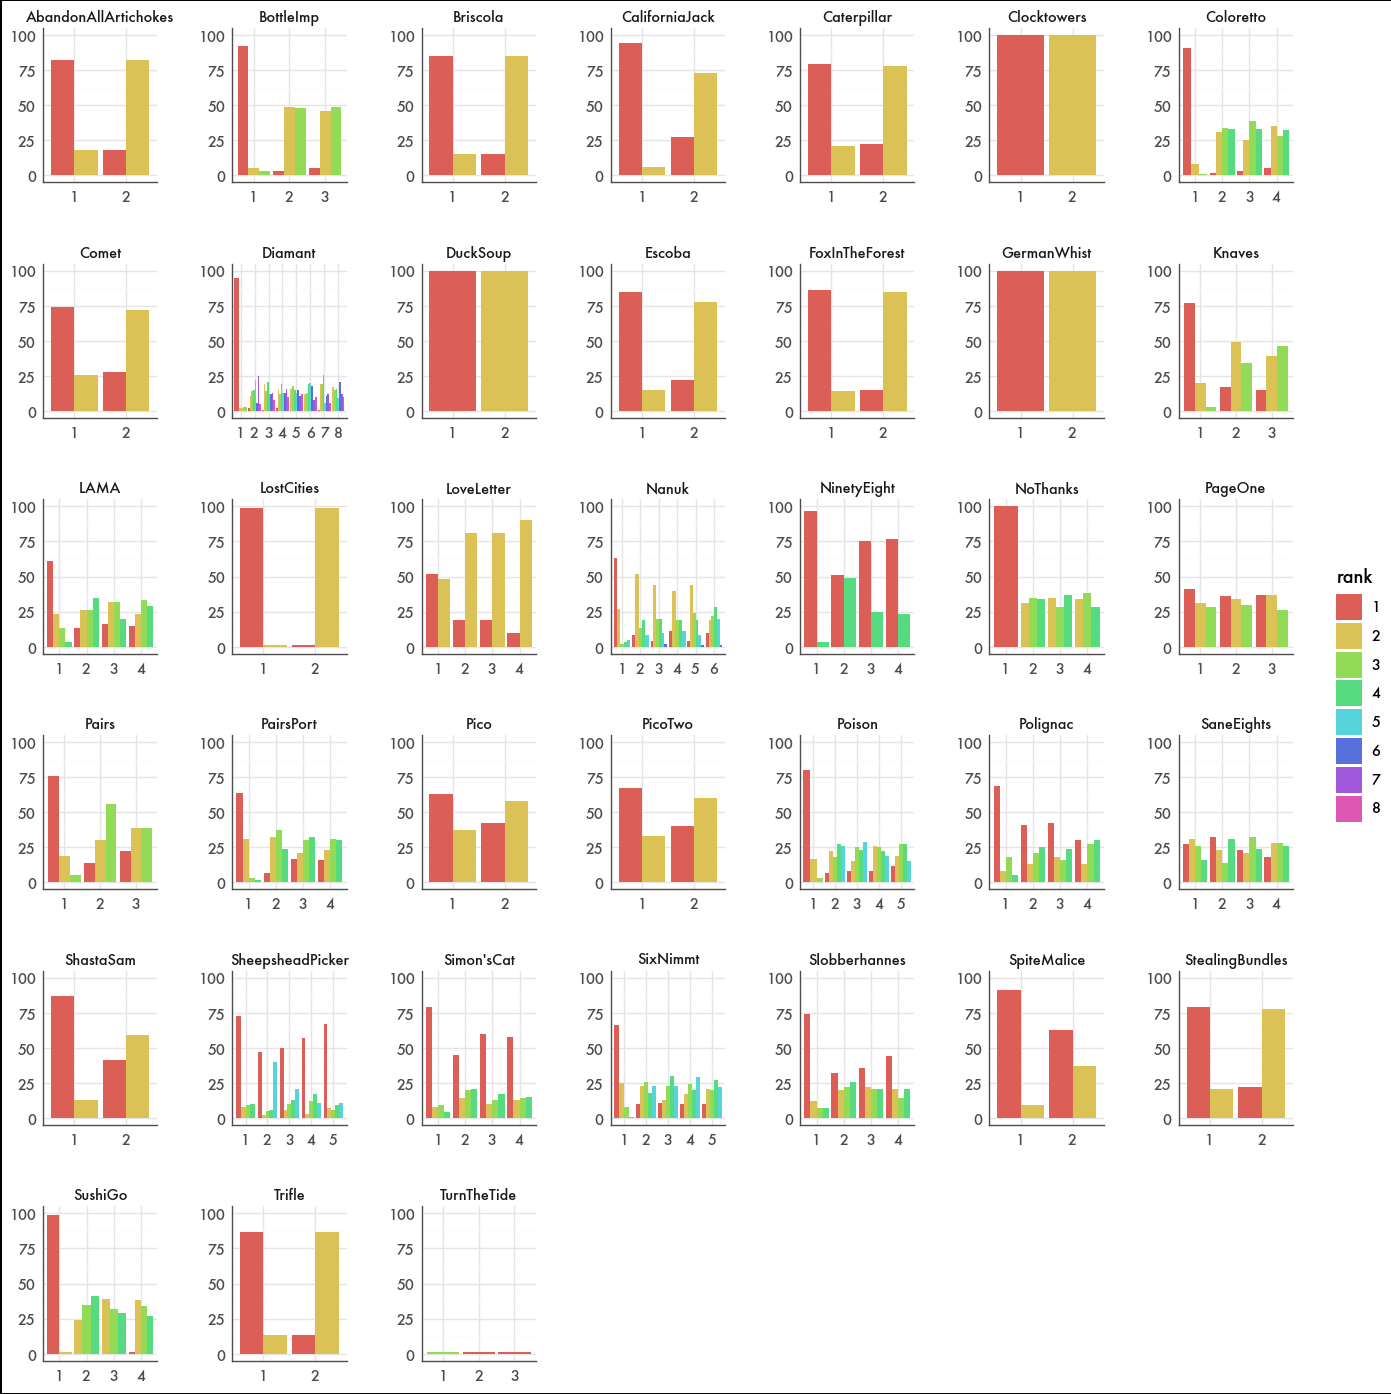

In [26]:
rplot = (ggplot(rf2, aes("player", "run", fill="rank"))
 + geom_bar(position="dodge", stat="identity")
 + facet_wrap("game", scales = "free", ncol=7)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(figure_size=(14, 14))
 + ylim(0, 100)
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + labs(x='player', y='rank')
)
rplot.save("AIRanks.png")
rplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 20 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: AllScores.png
/opt/anaconda3/lib/python3.13/site-packages/plotnine/stats/stat_density.py:182: PlotnineWarning: To compute the density of a group with only one value set the bandwidth manually. e.g `bw=0.1`
/opt/anaconda3/lib/python3.13/site-packages/plotnine/stats/stat_density.py:187: PlotnineWarning: Groups with fewer than 2 data points have been removed.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/stats/stat_density.py:182: PlotnineWarning: To compute the density of a group with only one value set the bandwidth manually. e.g `bw=0.1`
/opt/anaconda3/lib/python3.13/site-packages/plotnine/stats/stat_density.py:187: PlotnineWarning: Groups with fewer than 2 data points have been removed.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/stats/stat_density.py:182: PlotnineWar

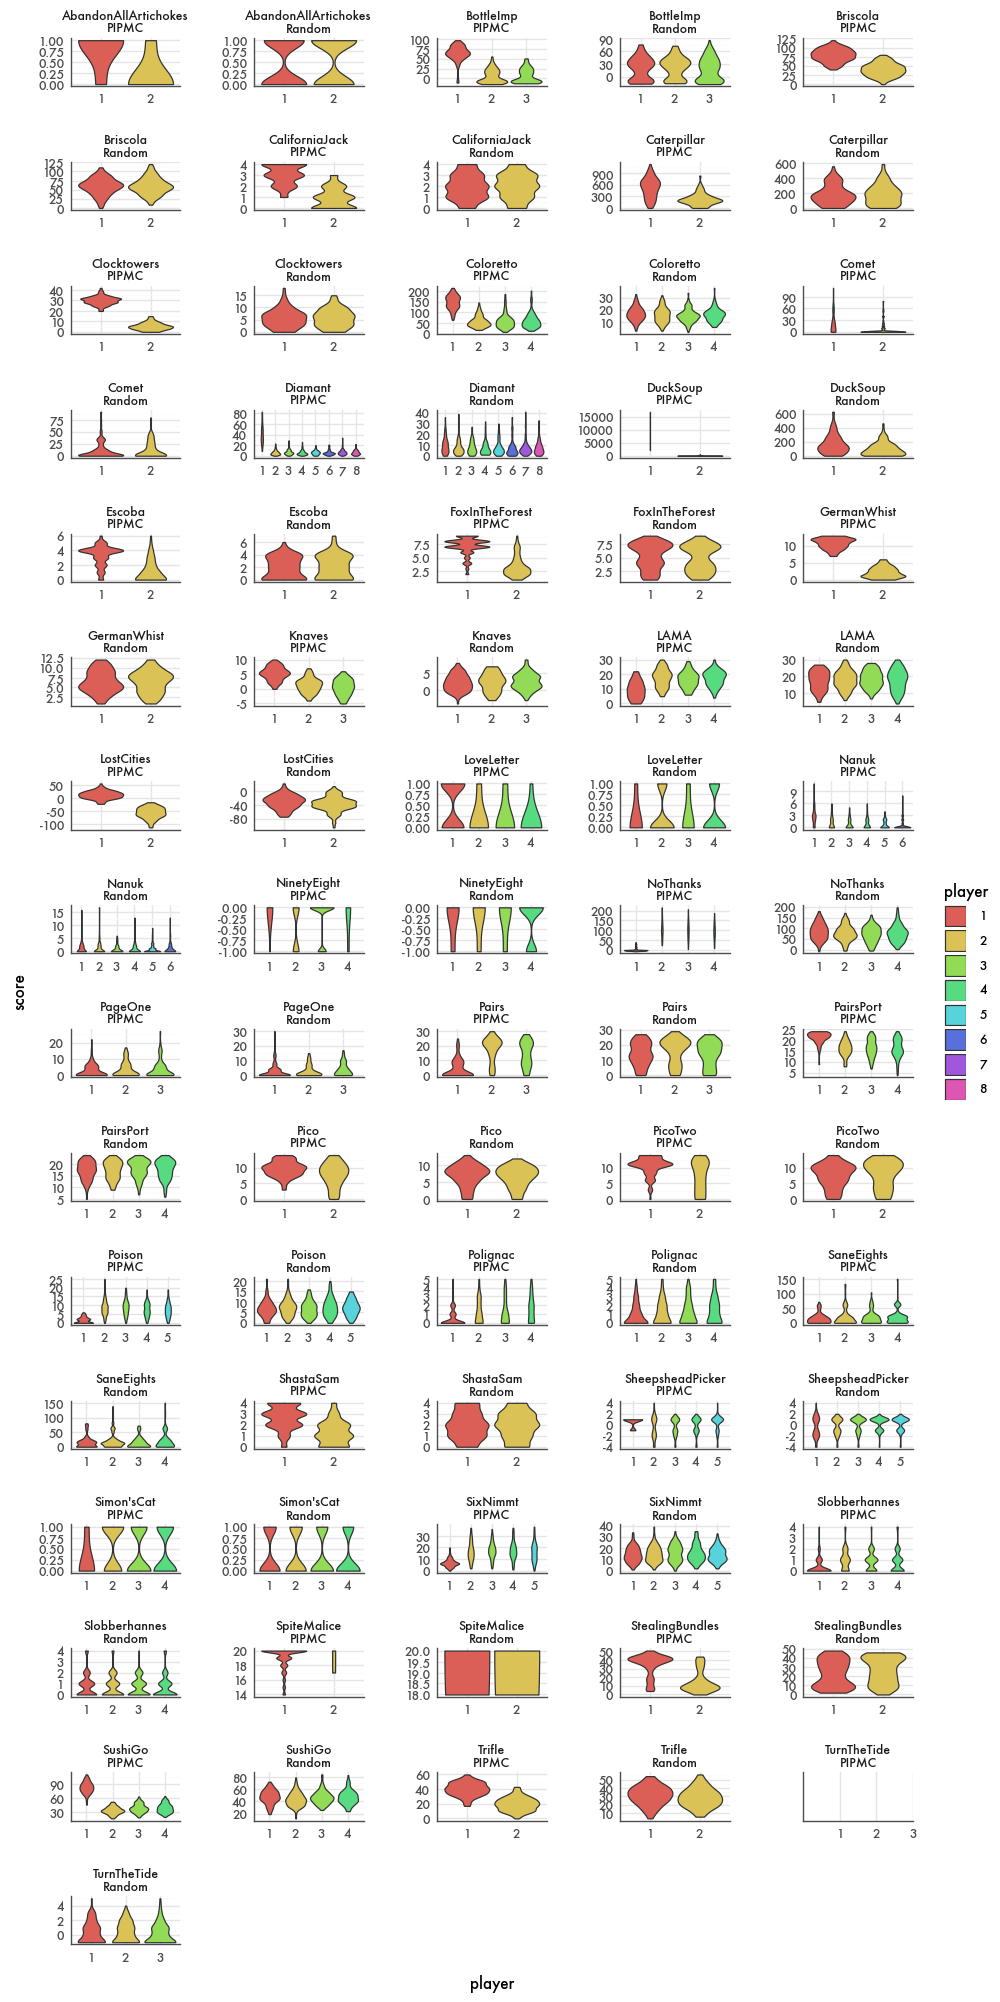

In [27]:
splot = (ggplot(resultsframe, aes("player", "score", fill="player"))
 + geom_violin()
 + facet_wrap(["game", "ai"], scales = "free", ncol = 5)
 + theme_minimal(base_family="Futura", base_size=11)
 + theme(figure_size=(10, 20))
 + theme(
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        panel_spacing=0.03,
    )
 + labs(x='player', y='score')
)
splot.save("AllScores.png")
splot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 8 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: PvsRScores.png


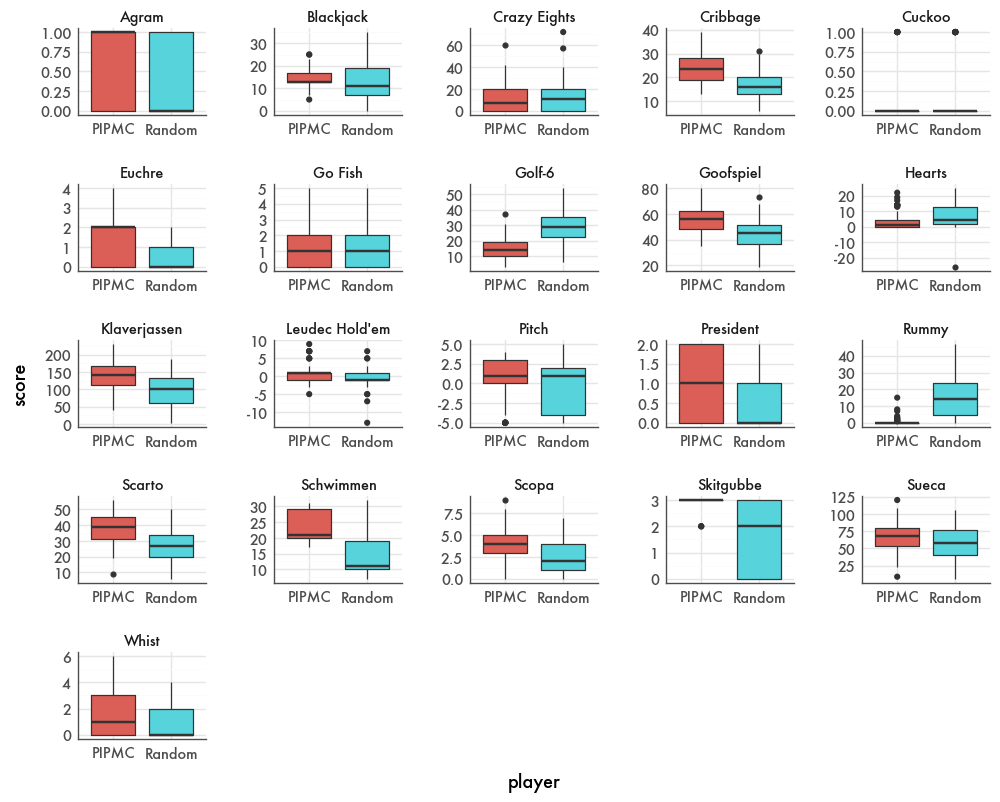

In [20]:
resultsframe["rank"] = resultsframe["rank"].astype(int)

splot = (ggplot(resultsframe[resultsframe["player"]=="1"], aes("ai", "score", fill="ai"))
 + geom_boxplot()
 + facet_wrap("name", scales = "free", ncol=5)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(10, 8))
 + theme(
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        panel_spacing=0.03,
    )
 + labs(x='player', y='score')
)
splot.save("PvsRScores.png")
splot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 6 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: MvsRScores.png


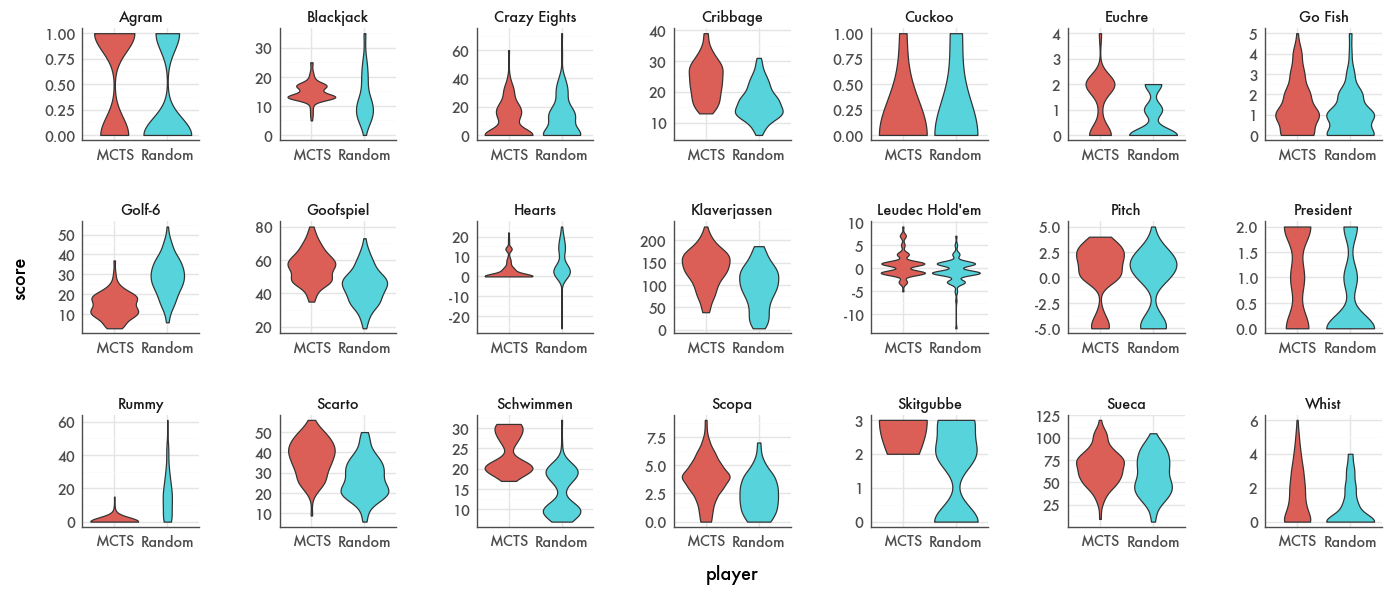

In [29]:
resultsframe["rank"] = resultsframe["rank"].astype(int)

splot = (ggplot(resultsframe[resultsframe["player"]=="1"], aes("ai", "score", fill="ai"))
 + geom_violin()
 + facet_wrap("name", scales = "free", ncol=7)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(14, 6))
 + theme(
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        panel_spacing=0.03,
    )
 + labs(x='player', y='score')
)
splot.save("MvsRScores.png")
splot.show()

In [15]:
def sig_code(pval):
    if pval < 0.001:
        return "***"
    elif pval < 0.01:
        return "**"
    elif pval < 0.05:
        return "*"
    elif pval < 0.1:
        return "."
    else:
        return ""
comp = resultsframe[resultsframe["player"]=="1"][["game", "ai", "run", "score"]]
comp = comp.pivot(index=["game", "run"], columns="ai", values="score")
comp2 = comp.groupby("game").apply(lambda df: st.ttest_ind(df['MCTS'], df['Random'])[1]).reset_index().rename(columns={0:"p-value"})[["game", "p-value"]]
comp3 = comp.groupby('game').apply(lambda df: sig_code(st.ttest_ind(df['MCTS'], df['Random'])[1])).reset_index().rename(columns={0:"significance"})
comp4 = comp3.merge(comp2, on="game", how="left").sort_values(by="p-value")
comp4

,game,significance,p-value
16,Schwimmen,***,1.201839e-29
9,GolfSix,***,1.586912e-27
2,BlockRummy,***,5.448703e-25
18,Skittgube,***,4.631452e-23
4,Cribbage,***,1.583263e-15
7,GOPS,***,1.038922e-13
15,Scarto,***,1.335103e-12
11,Klaverjassen,***,1.883948e-09
17,Scopa,***,1.159340e-06
6,Euchre,***,6.986509e-06


# Spread

In [121]:
first = True
for index, row in gameframe.iterrows():
    if row["game"] != "Blackjack":
        gf = pd.read_csv(row["fileprefix"] + row["game"] + "/" + str(row["player"]) + "/" + "P" + "R" * (row["player"] - 1) + "/spread.csv")
        gf["game"] = row["game"]
        if row["game"] == "Schwimmen":
            gf["spread"] = gf["spread"] / 2.0
        if first:
            spreadframe = gf
            first = False
        else:
            spreadframe = pd.concat([spreadframe, gf])
spreadframe["player"] = spreadframe["player"].astype(str)
spreadframe["run"] = spreadframe["run"].astype(str)

In [122]:
spreadframe

,game,numPlayers,ai,run,pmove,player,spread
0,Agram,3,PRR,1,1,0,0.142
1,Agram,3,PRR,1,2,0,0.093
2,Agram,3,PRR,1,3,0,0.025
3,Agram,3,PRR,1,4,0,0.169
4,Agram,3,PRR,1,5,0,0.054
...,...,...,...,...,...,...,...
1295,Whist,4,PRRR,100,9,0,0.000
1296,Whist,4,PRRR,100,10,0,0.000
1297,Whist,4,PRRR,100,11,0,0.000
1298,Whist,4,PRRR,100,12,0,0.000


/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Spread.png


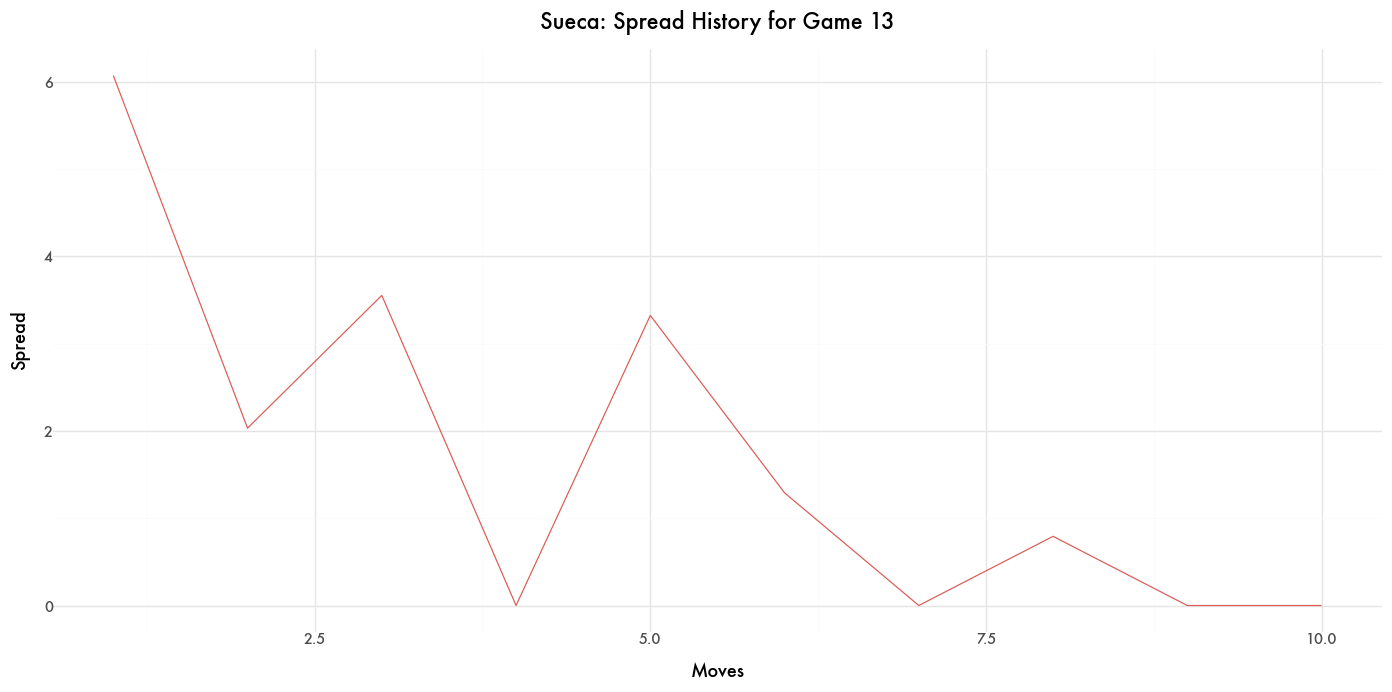

In [124]:
game = "Sueca"
iter = "13"
splot = (ggplot(spreadframe[(spreadframe["run"] == iter) & (spreadframe["game"] == game)], 
       aes(x="pmove", y="spread", color="player"))
 + geom_line()
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(14, 7))
 + labs(x='Moves', y='Spread', title=game + ": Spread History for Game " + str(iter))
)
splot.save("Spread.png")
splot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Spread.png


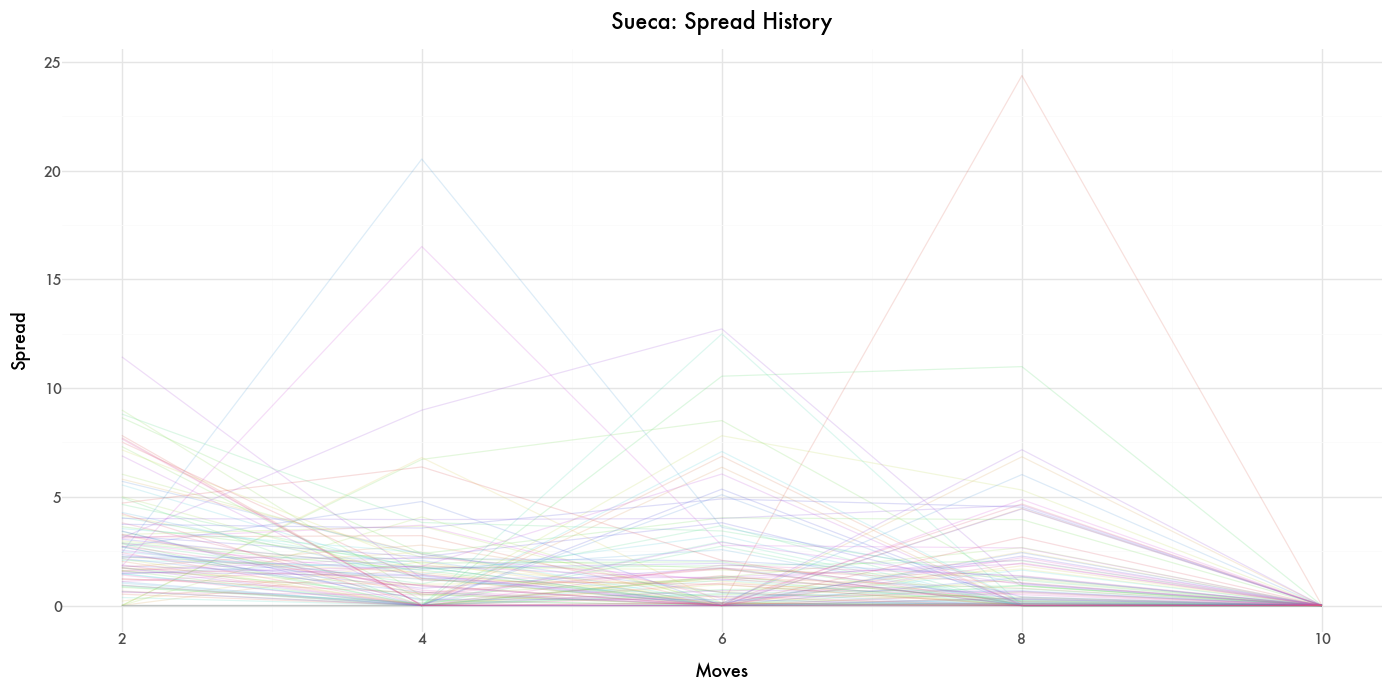

In [125]:
splot = (ggplot(spreadframe[(spreadframe["game"] == game) & (spreadframe["pmove"]%2 == 0)], 
       aes(x="pmove", y="spread", color="run"))
 + geom_line(alpha=0.2)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(14, 7))
 + labs(x='Moves', y='Spread', title=game + ": Spread History")
)
splot.save("Spread.png")
splot.show()

In [126]:
spreadframe[(spreadframe["game"] == game)]

,game,numPlayers,ai,run,pmove,player,spread
0,Sueca,4,PRRR,1,1,0,5.871
1,Sueca,4,PRRR,1,2,0,7.821
2,Sueca,4,PRRR,1,3,0,1.106
3,Sueca,4,PRRR,1,4,0,0.000
4,Sueca,4,PRRR,1,5,0,1.146
...,...,...,...,...,...,...,...
995,Sueca,4,PRRR,100,6,0,1.376
996,Sueca,4,PRRR,100,7,0,0.552
997,Sueca,4,PRRR,100,8,0,0.195
998,Sueca,4,PRRR,100,9,0,0.024


/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 8 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Spread.png
/opt/anaconda3/lib/python3.13/site-packages/plotnine/geoms/geom_path.py:113: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?
/opt/anaconda3/lib/python3.13/site-packages/plotnine/geoms/geom_path.py:113: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


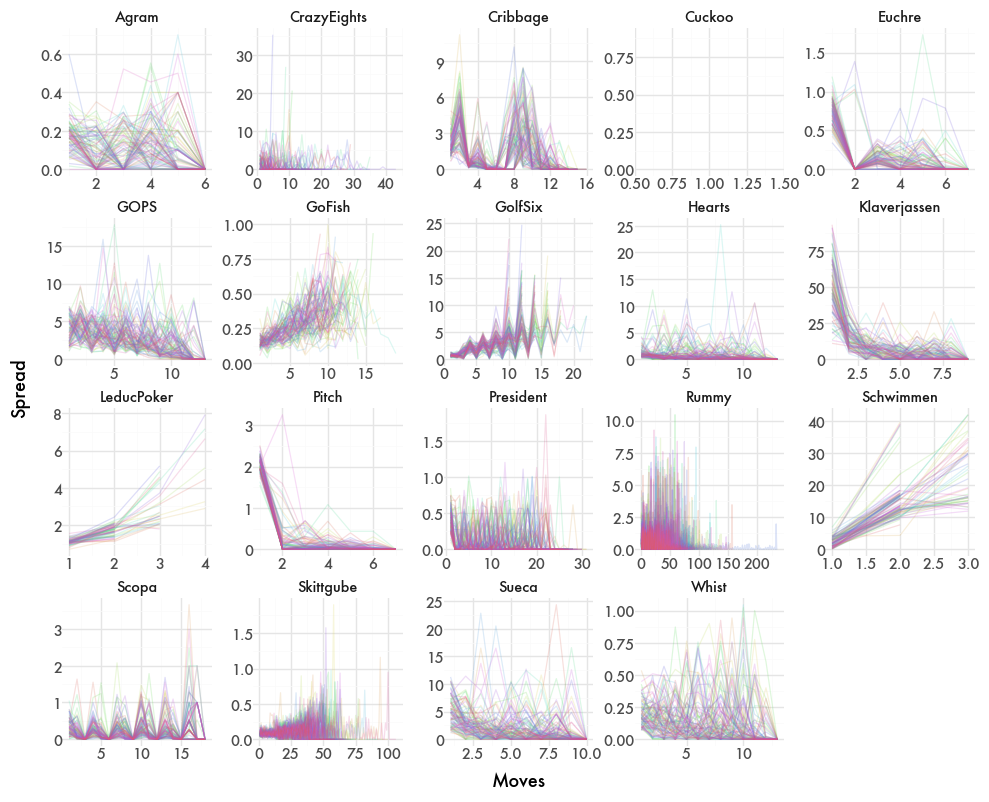

In [129]:
splot = (ggplot(spreadframe, 
       aes(x="pmove", y="spread", color="run"))
 + geom_line(alpha=0.2)
 + facet_wrap("game", scales = "free", ncol=5)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(10, 8))
 + labs(x='Moves', y='Spread')
)
splot.save("Spread.png")
splot.show()

# Lead History 

First, we create the Dataframe for storing all of the game statistics for the lead histories, then we can use this to project multiple graphs.

The **Security** and **Drama** Heuristics are calculated as part of this process.

In [61]:
first = True
for index, row in gameframe.iterrows():
    if row["game"] != "Blackjack" and row["game"] != "GoFish" and row["game"] != "Rummy" and row["game"] != "Skittgube":
        #gf = pd.read_csv(row["fileprefix"] + row["game"] + "/" + str(row["player"]) + "/" + "P" + "R" * (row["player"] - 1) + "/lead.csv")
        gf = pd.read_csv(fileprefix + row["game"] + "/" + str(row["player"]) + "/" + "PPPPPP" + "/lead.csv")
        gf["game"] = row["game"]
        if first:
            leadframe = gf
            first = False
        else:
            leadframe = pd.concat([leadframe, gf])
leadframe

,game,numPlayers,ai,run,move,recorder,player,score,rank,rankestimate
0,Agram,3,PPPPPP,1,1,1,1,0.76,1,0.880000
1,Agram,3,PPPPPP,1,1,1,2,0.12,3,0.560000
2,Agram,3,PPPPPP,1,1,1,3,0.12,2,0.560000
3,Agram,3,PPPPPP,1,2,2,1,0.42,1,0.710000
4,Agram,3,PPPPPP,1,2,2,2,0.26,3,0.630000
...,...,...,...,...,...,...,...,...,...,...
21195,Whist,4,PPPPPP,100,52,3,4,0.00,3,0.333333
21196,Whist,4,PPPPPP,100,53,1,1,2.00,2,1.000000
21197,Whist,4,PPPPPP,100,53,2,2,0.00,4,0.333333
21198,Whist,4,PPPPPP,100,53,3,3,2.00,1,1.000000


In [62]:
leadframe[(leadframe["game"]=="Rummy") & (leadframe["run"] == 1)]

,game,numPlayers,ai,run,move,recorder,player,score,rank,rankestimate


In [63]:
leadframe[leadframe['rank'].isnull()]

,game,numPlayers,ai,run,move,recorder,player,score,rank,rankestimate


In [64]:
first = True
for game in gameframe["game"]:
    if game != "Blackjack" and game != "GoFish" and game != "Rummy" and game != "Skittgube":
        print(game)
        pv = gameframe[gameframe["game"] == game]["player"].values[0]
        myl = leadframe[leadframe["game"] == game]
        for run in range(1, 101):
            for player in range(1, pv + 1):
                myl2 = myl[(myl["run"] == run)  & (myl["player"] == player)]
                x = myl2["rankestimate"]
                length = myl2["move"].max()
                px = [x / (length - 1) for x in range(length)]
                f = interp1d(px, x)
                xnew = np.linspace(0, 1, num=101)
                ynew = f(xnew)
                n = pd.DataFrame([xnew, ynew], index=["portion", "estimate"]).T
                n["game"] = game
                n["run"] = run
                n["player"] = player
                n["rank"] = myl2["rank"].values[0]
                if first:
                    leads = n
                    first = False
                else:
                    leads = pd.concat([leads, n])

Agram
CrazyEights
Cribbage
Cuckoo
Euchre
GolfSix
GOPS
Hearts
Klaverjassen
LeducPoker
Pitch
President
Schwimmen
Scopa
Sueca
Whist


In [65]:
leads

,portion,estimate,game,run,player,rank
0,0.00,0.880000,Agram,1,1,1
1,0.01,0.849400,Agram,1,1,1
2,0.02,0.818800,Agram,1,1,1
3,0.03,0.788200,Agram,1,1,1
4,0.04,0.757600,Agram,1,1,1
...,...,...,...,...,...,...
96,0.96,0.333333,Whist,100,4,3
97,0.97,0.333333,Whist,100,4,3
98,0.98,0.333333,Whist,100,4,3
99,0.99,0.333333,Whist,100,4,3


In [66]:
leads["player"] = leads["player"].astype(str)
leads["run"] = leads["run"].astype(str)
leads["rank"] = leads["rank"].astype(str)
leads[(leads["game"] == "Cuckoo") & (leads["run"] == "1")]

,portion,estimate,game,run,player,rank
0,0.00,1.00000,Cuckoo,1,1,1
1,0.01,0.99616,Cuckoo,1,1,1
2,0.02,0.99232,Cuckoo,1,1,1
3,0.03,0.98848,Cuckoo,1,1,1
4,0.04,0.98464,Cuckoo,1,1,1
...,...,...,...,...,...,...
96,0.96,1.00000,Cuckoo,1,6,5
97,0.97,1.00000,Cuckoo,1,6,5
98,0.98,1.00000,Cuckoo,1,6,5
99,0.99,1.00000,Cuckoo,1,6,5


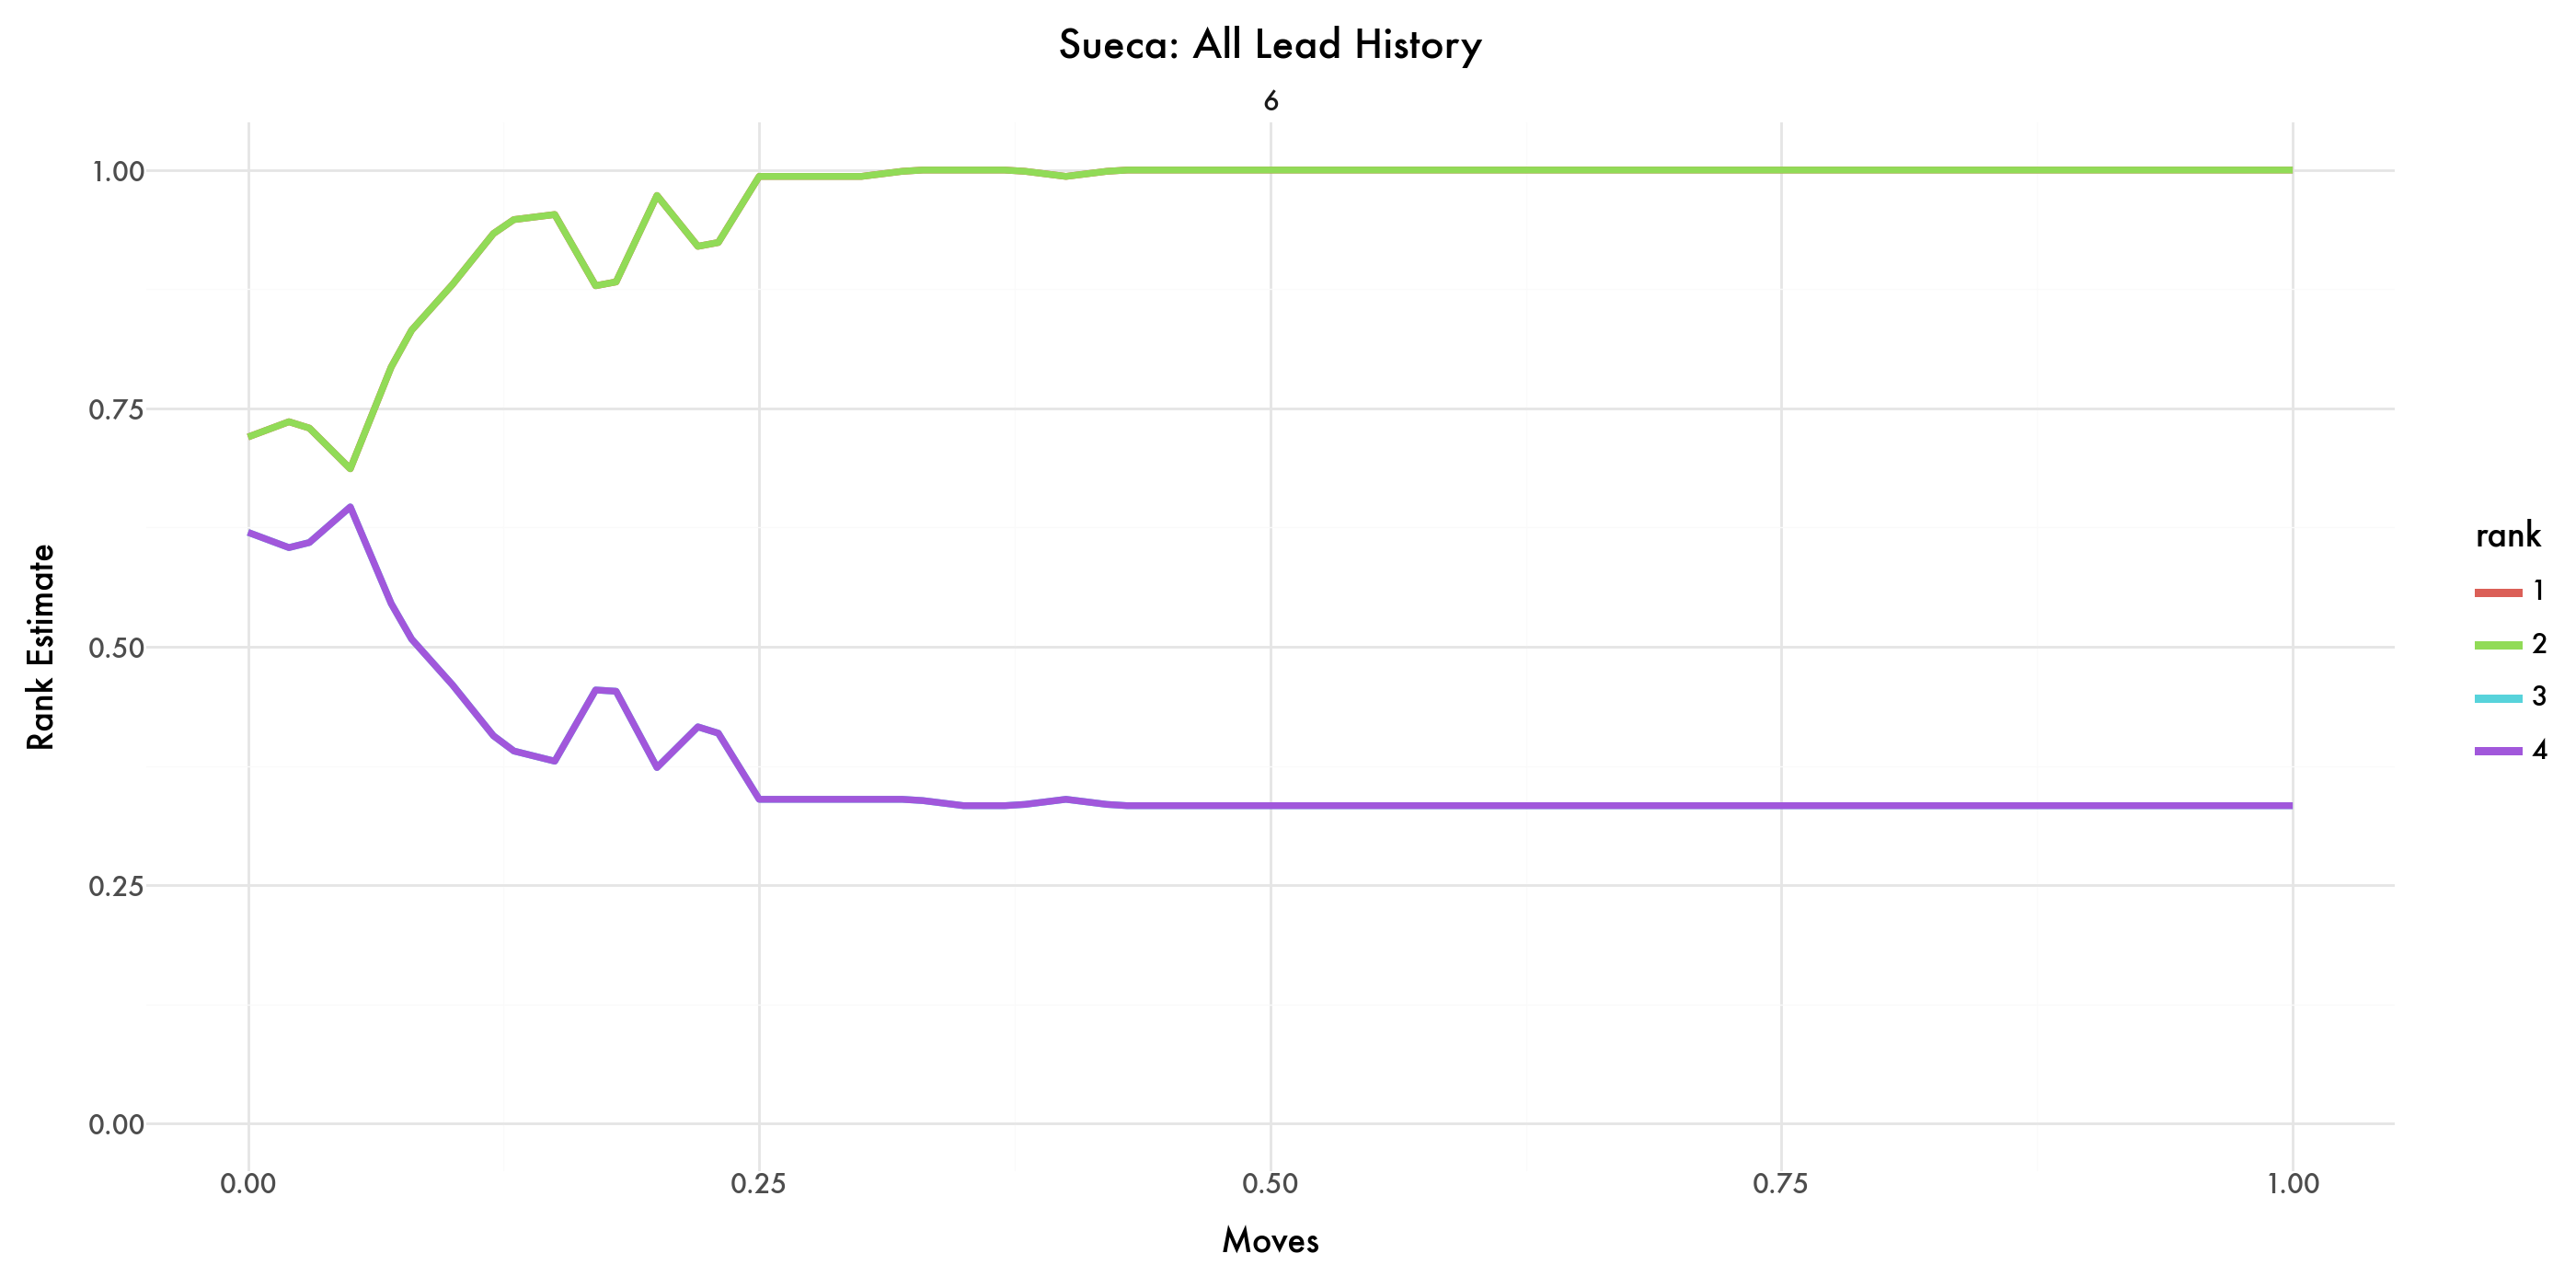

In [68]:
game = "Sueca"
iter="6"
(ggplot(leads[(leads["game"] == game) & (leads["run"]== iter)], 
       aes(x="portion", y="estimate", color="rank"))
 + geom_line(size=1.5)
 + ylim(0, 1)
 + facet_wrap("run", scales = "free_x")
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(figure_size=(14, 7))
 + labs(x='Moves', y='Rank Estimate', title=game + ": All Lead History")
)

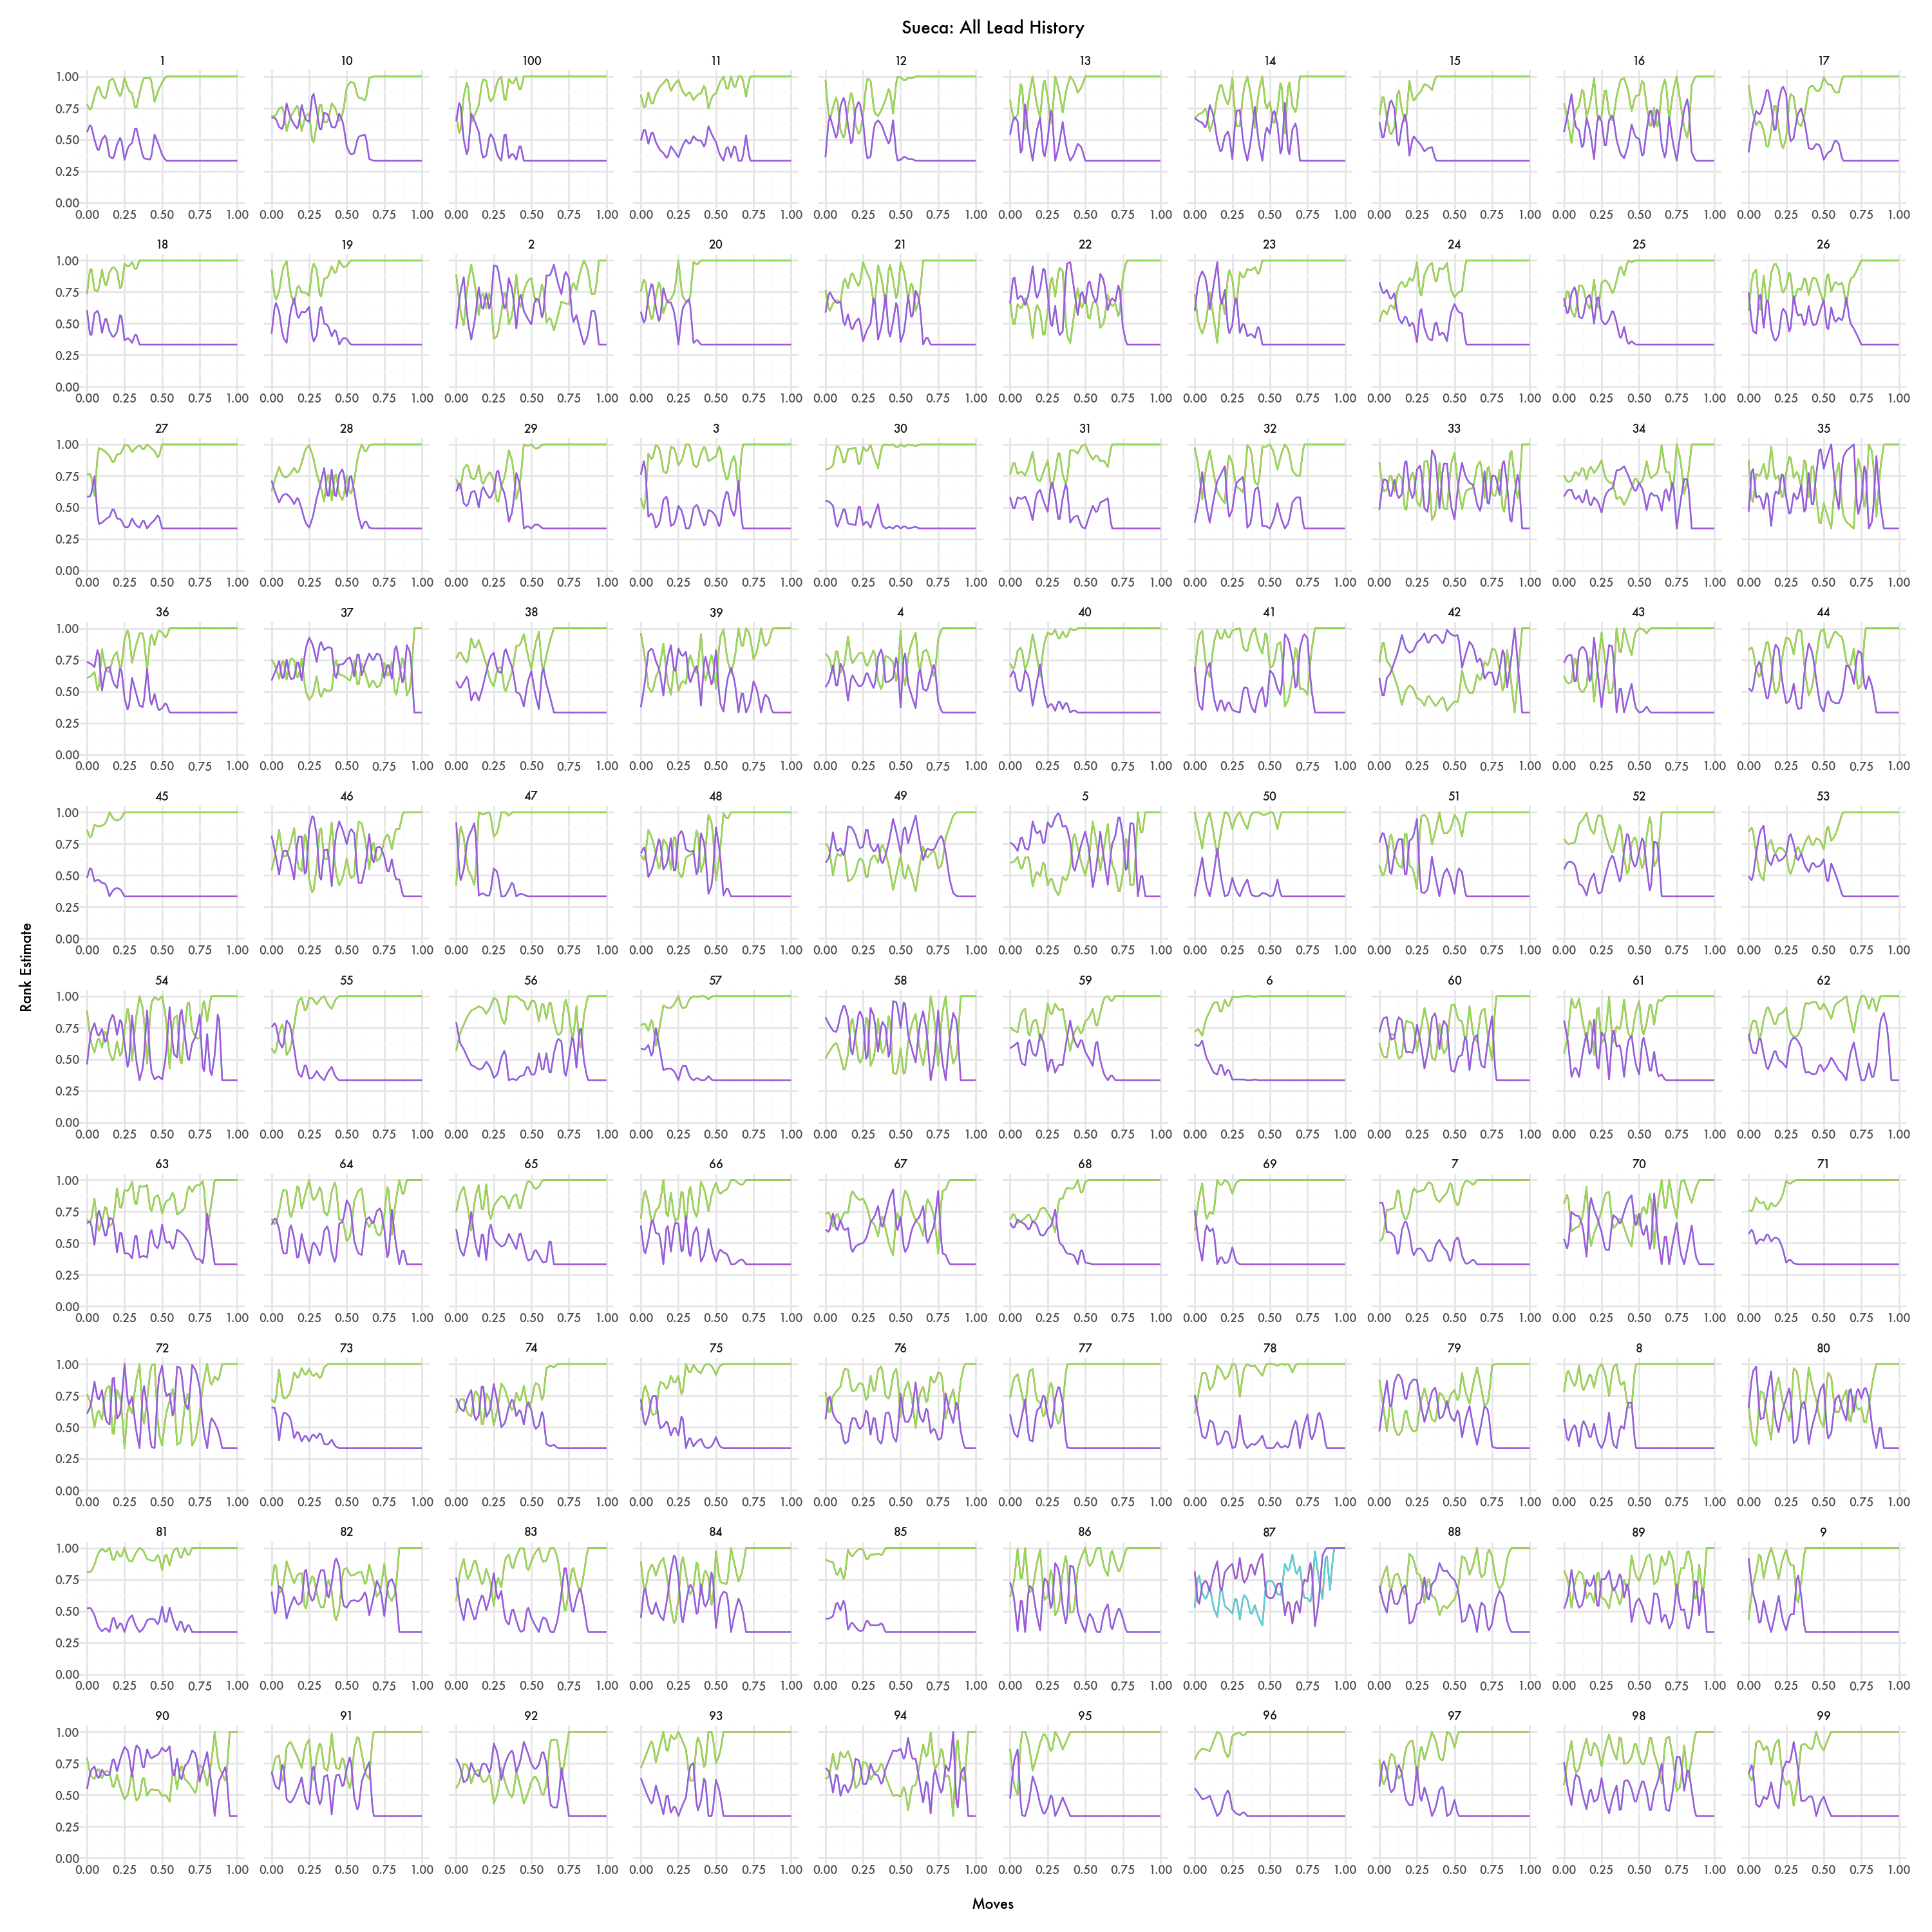

In [69]:
(ggplot(leads[(leads["game"] == game)], 
       aes(x="portion", y="estimate", color="rank"))
 + geom_line()
 + ylim(0, 1)
 + facet_wrap("run", scales = "free_x")
 + theme_minimal(base_family="Futura", base_size=8)
 + theme(legend_position='none', figure_size=(15, 15))
 + labs(x='Moves', y='Rank Estimate', title=game + ": All Lead History")
)

/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_smooth : Removed 4 rows containing missing values.


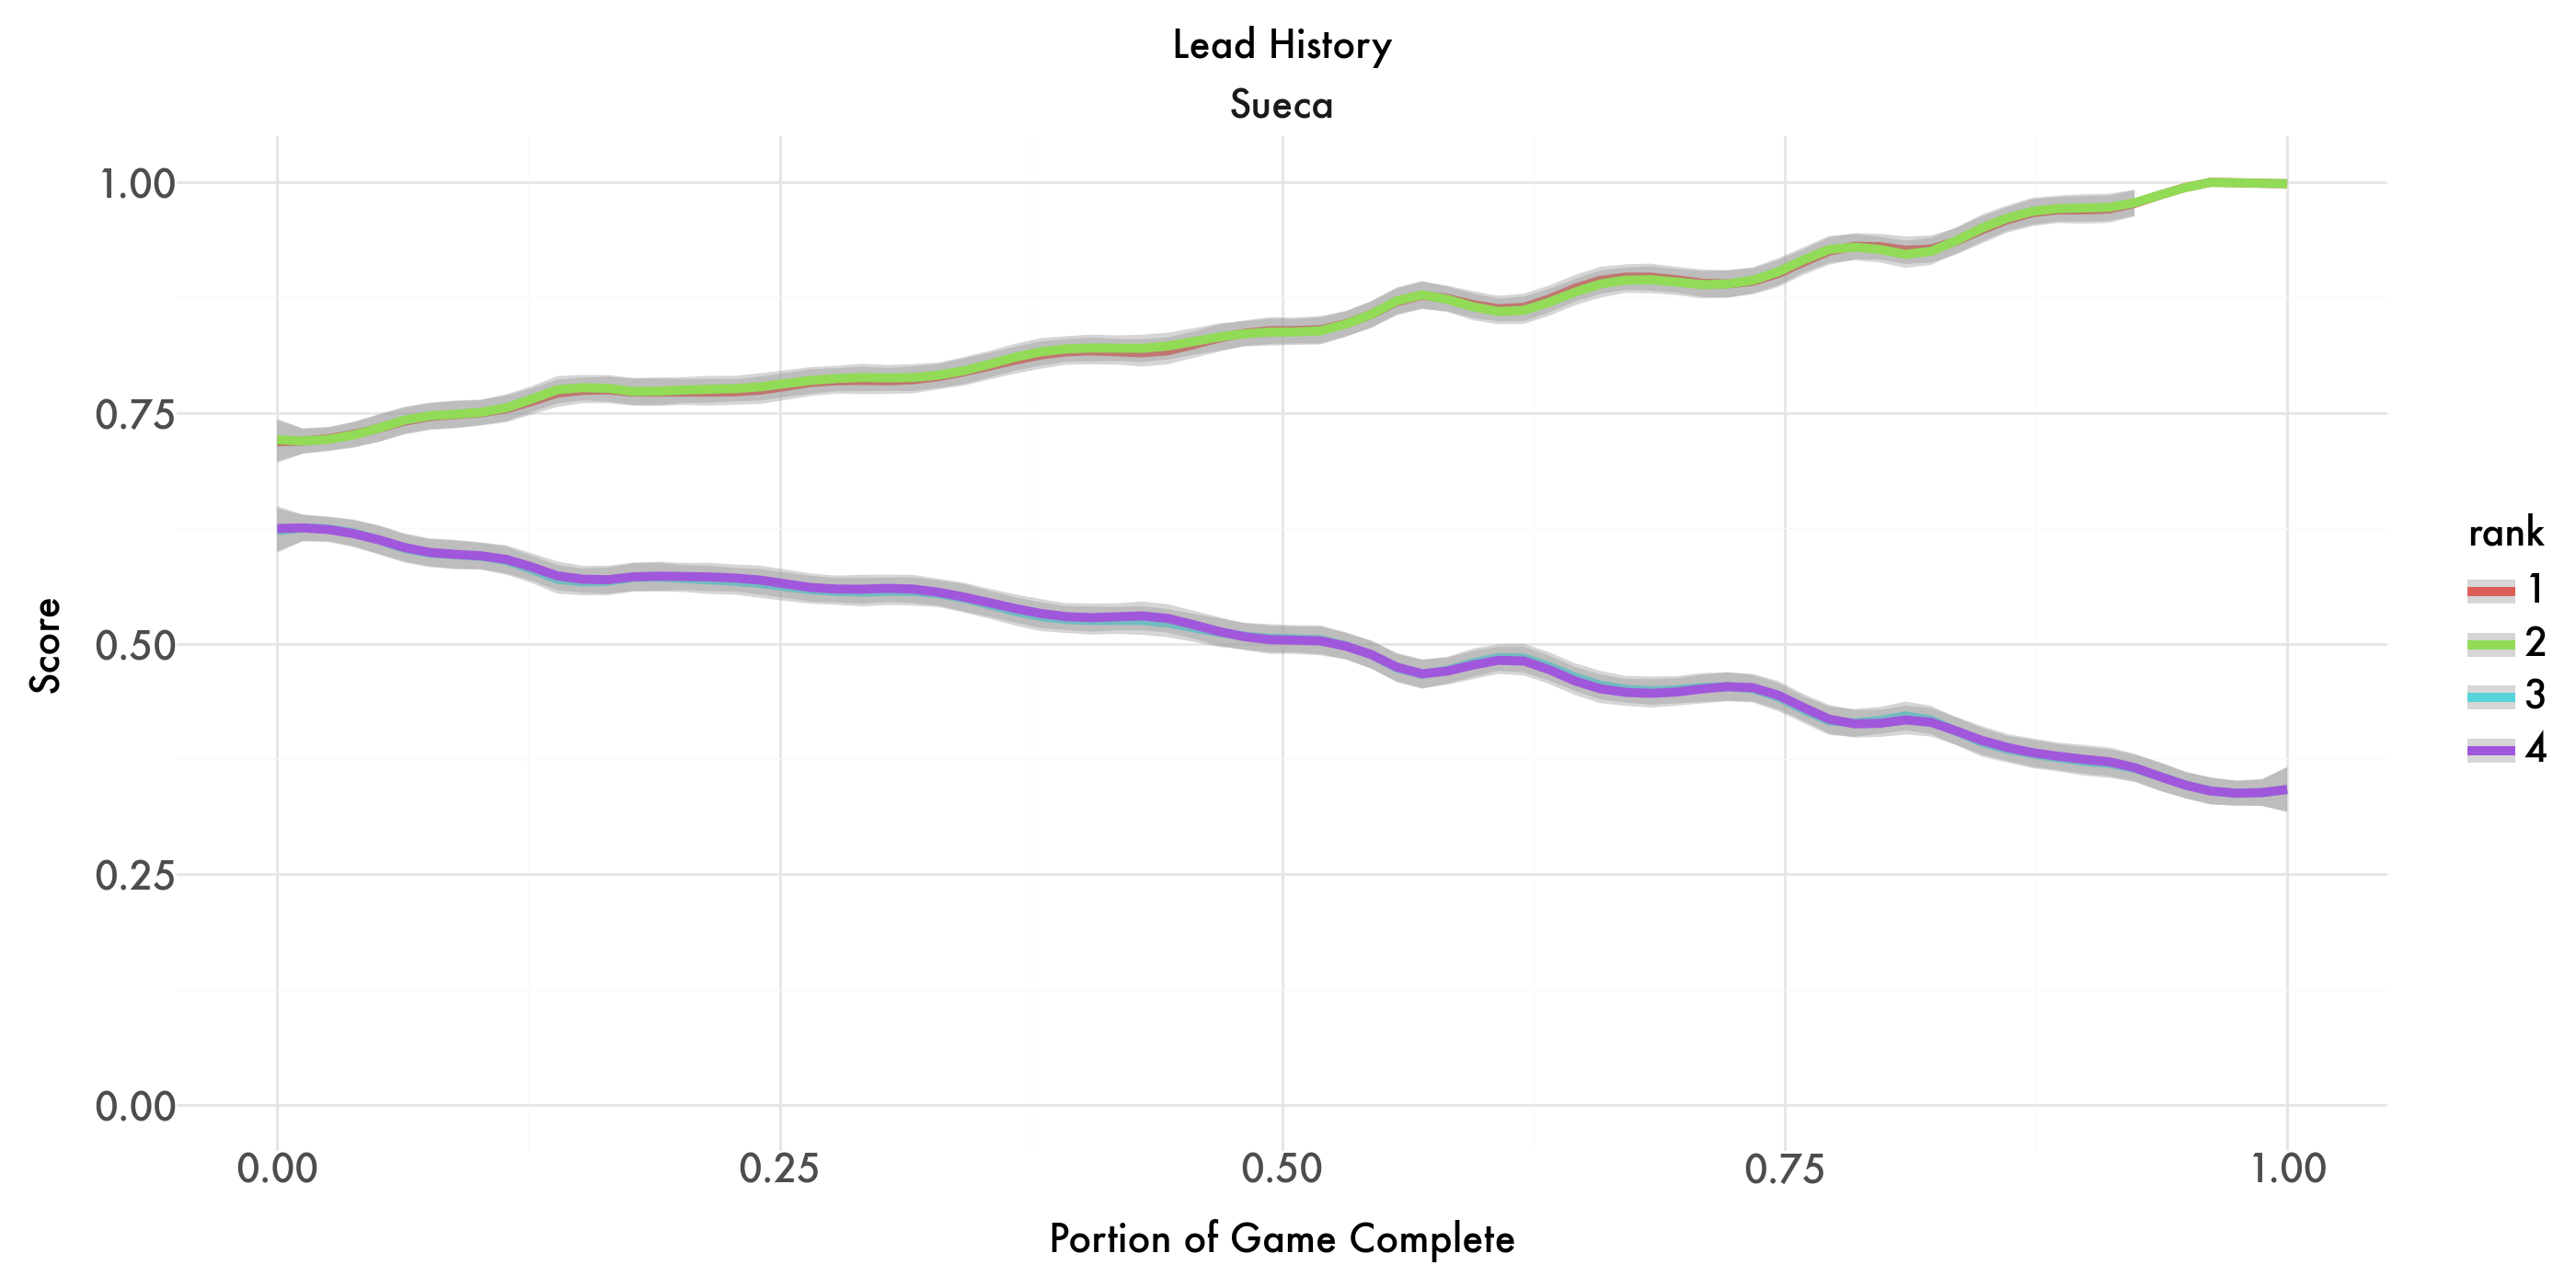

In [70]:

(ggplot(leads[(leads["game"] == game)], 
       aes(x="portion", y="estimate", color="rank"))
    + geom_smooth(method="loess", size=2, span=0.1)
    + ylim(0, 1)
    + facet_wrap("game")
    + theme_minimal(base_family="Futura", base_size=13)
    + theme(figure_size=(14, 7), text=element_text(size=15))
    + labs(x='Portion of Game Complete', y='Score', title="Lead History")
)


/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 5 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: LeadHistory.png
/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_smooth : Removed 46 rows containing missing values.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_smooth : Removed 46 rows containing missing values.


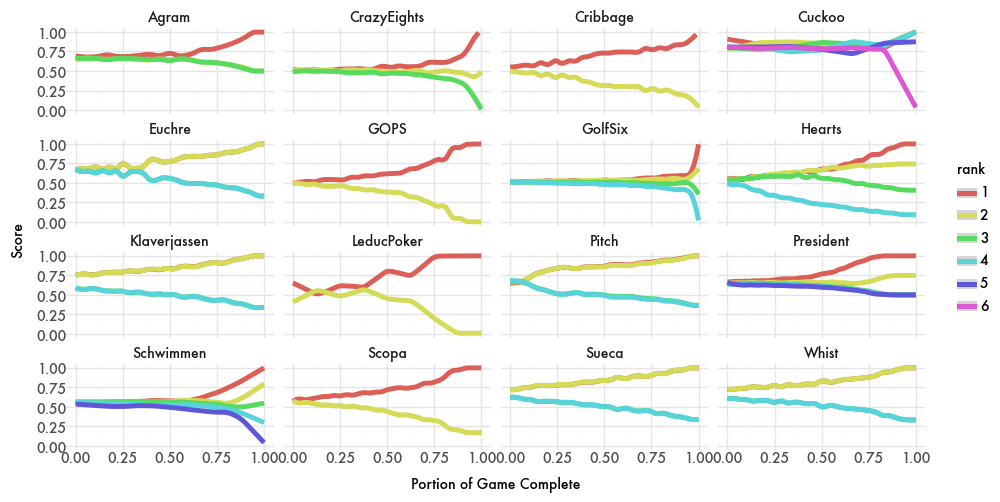

In [74]:
lh = (ggplot(leads, aes(x="portion", y="estimate", color="rank"))
    + geom_smooth(method="loess", size=2, span=0.1)
    + ylim(0, 1)
    + facet_wrap("game")
    + theme_minimal(base_family="Futura", base_size=10)
    + theme(figure_size=(10, 5), text=element_text(size=10))
    + labs(x='Portion of Game Complete', y='Score')
)
lh.save("LeadHistory.png")
lh.show()

In [60]:
(ggplot(leads, aes(x="portion", y="estimate", color="rank"))
    + geom_smooth(method="loess", size=2, span=0.1)
    + ylim(0, 1)
    + facet_wrap("game")
    + theme_minimal(base_family="Futura", base_size=10)
    + theme(figure_size=(14, 7), text=element_text(size=10))
    + labs(x='Portion of Game Complete', y='Score', title="Lead History")
)

KeyboardInterrupt: 

Use the following graph to look for turn order advantage.

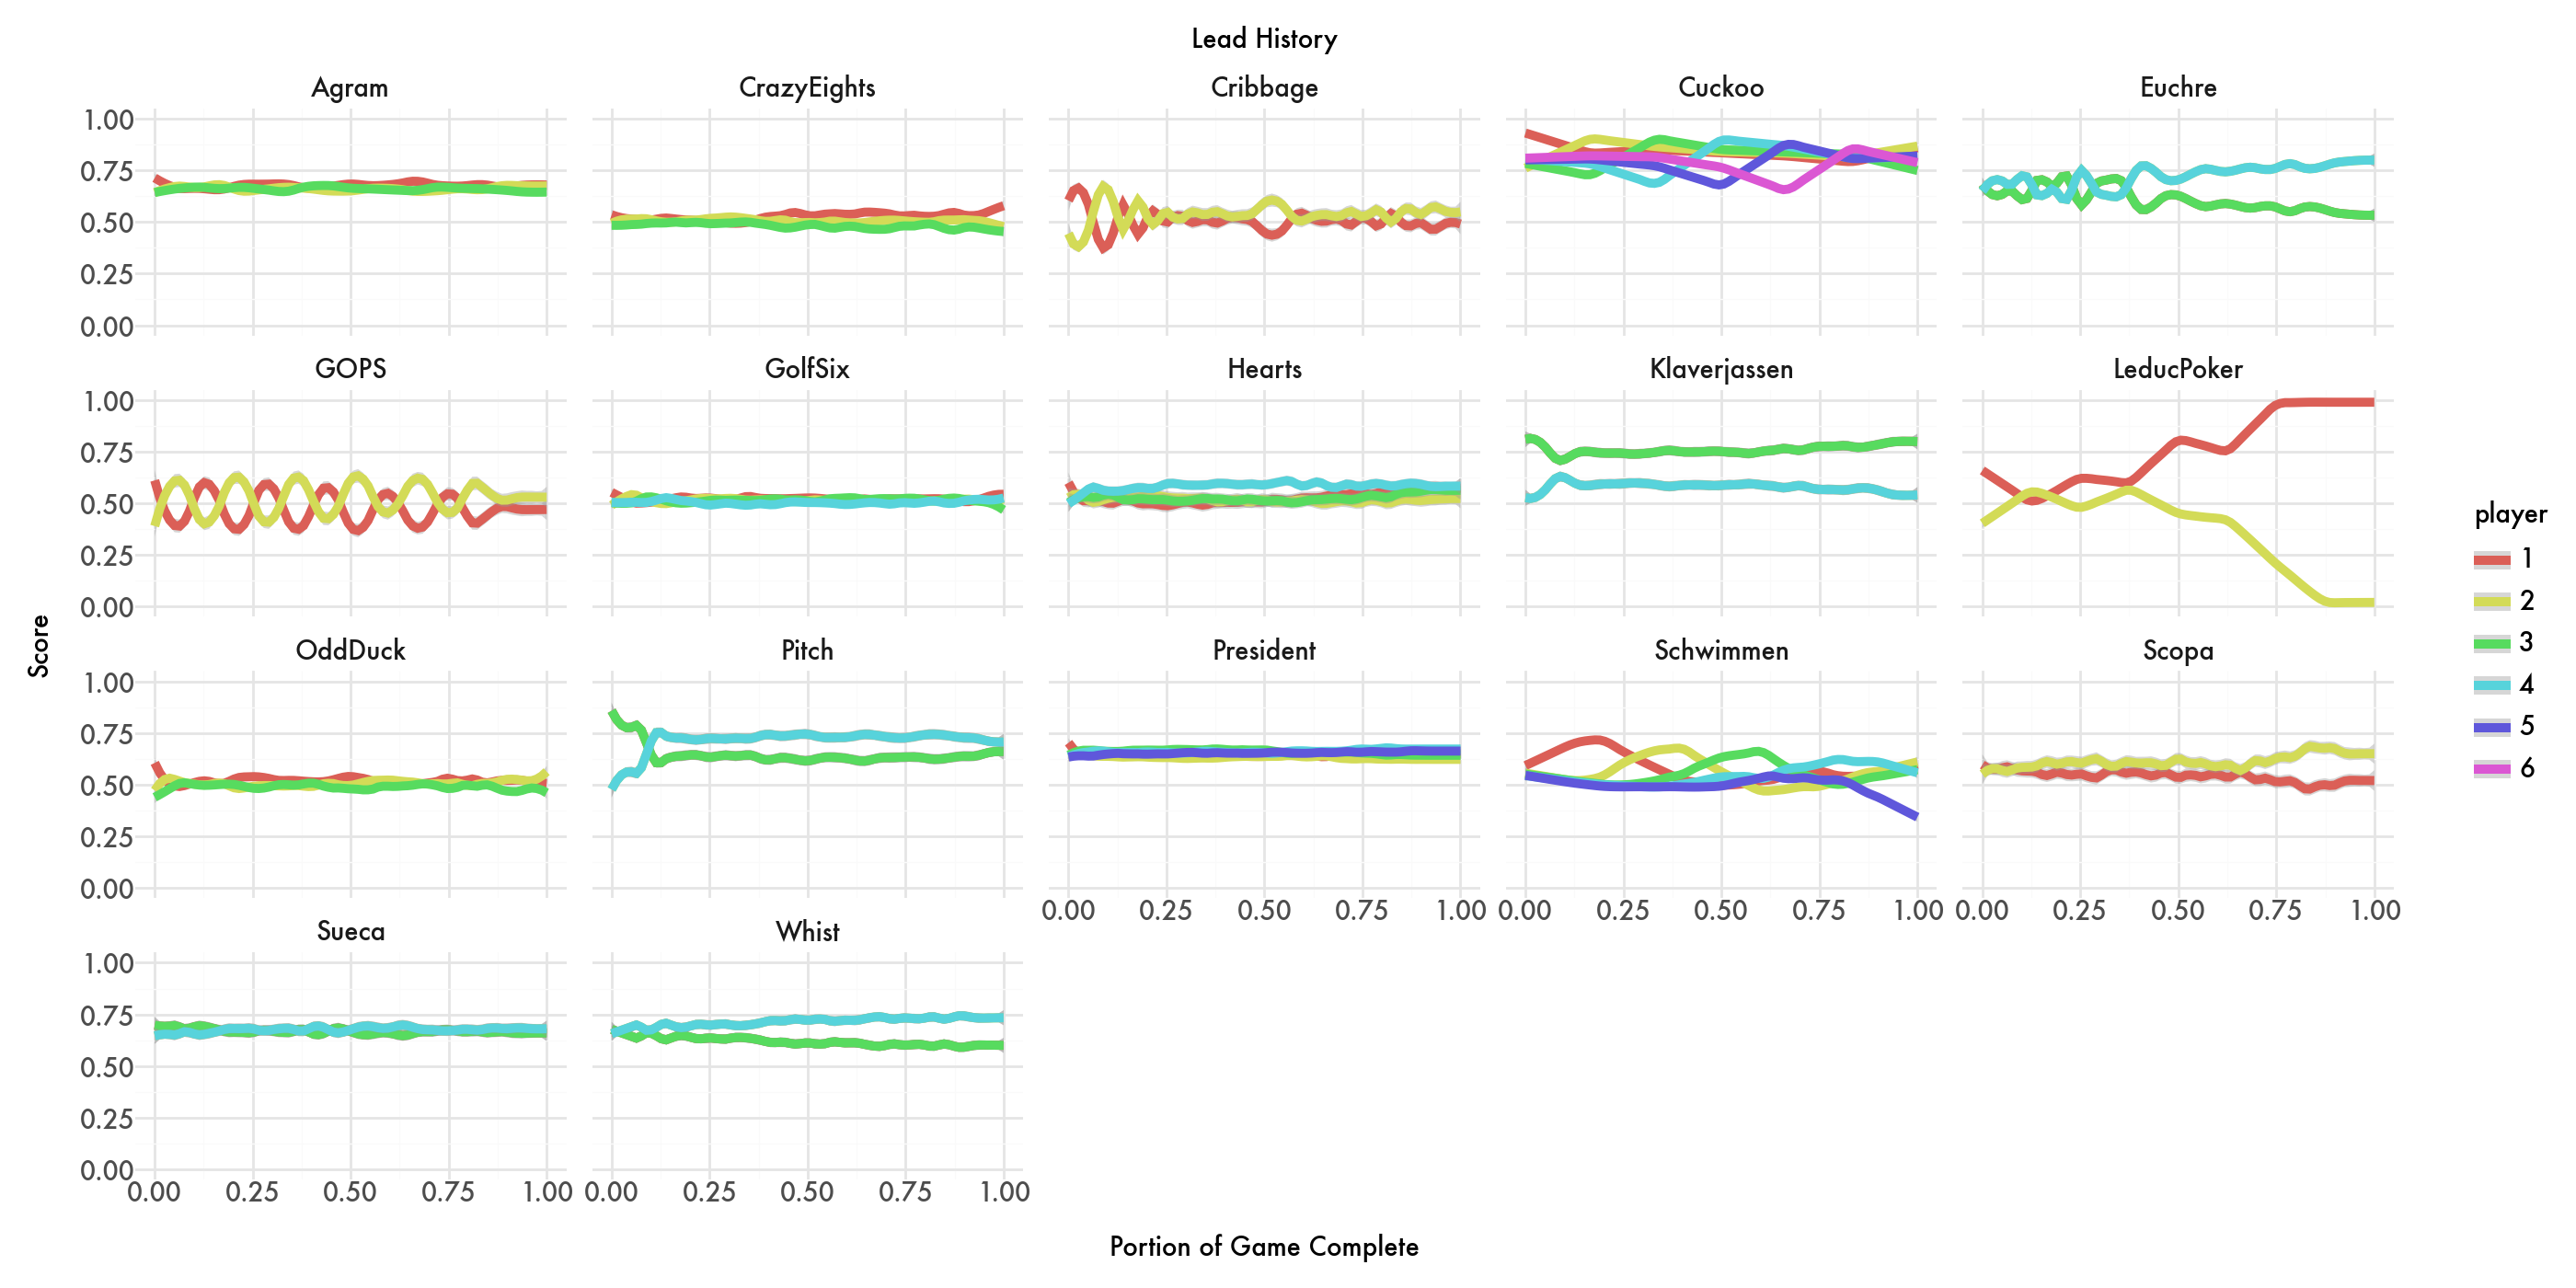

In [13]:
(ggplot(leads, aes(x="portion", y="estimate", color="player"))
    + geom_smooth(method="loess", size=2, span=0.1)
    + ylim(0, 1)
    + facet_wrap("game")
    + theme_minimal(base_family="Futura", base_size=10)
    + theme(figure_size=(14, 7), text=element_text(size=10))
    + labs(x='Portion of Game Complete', y='Score', title="Lead History")
)

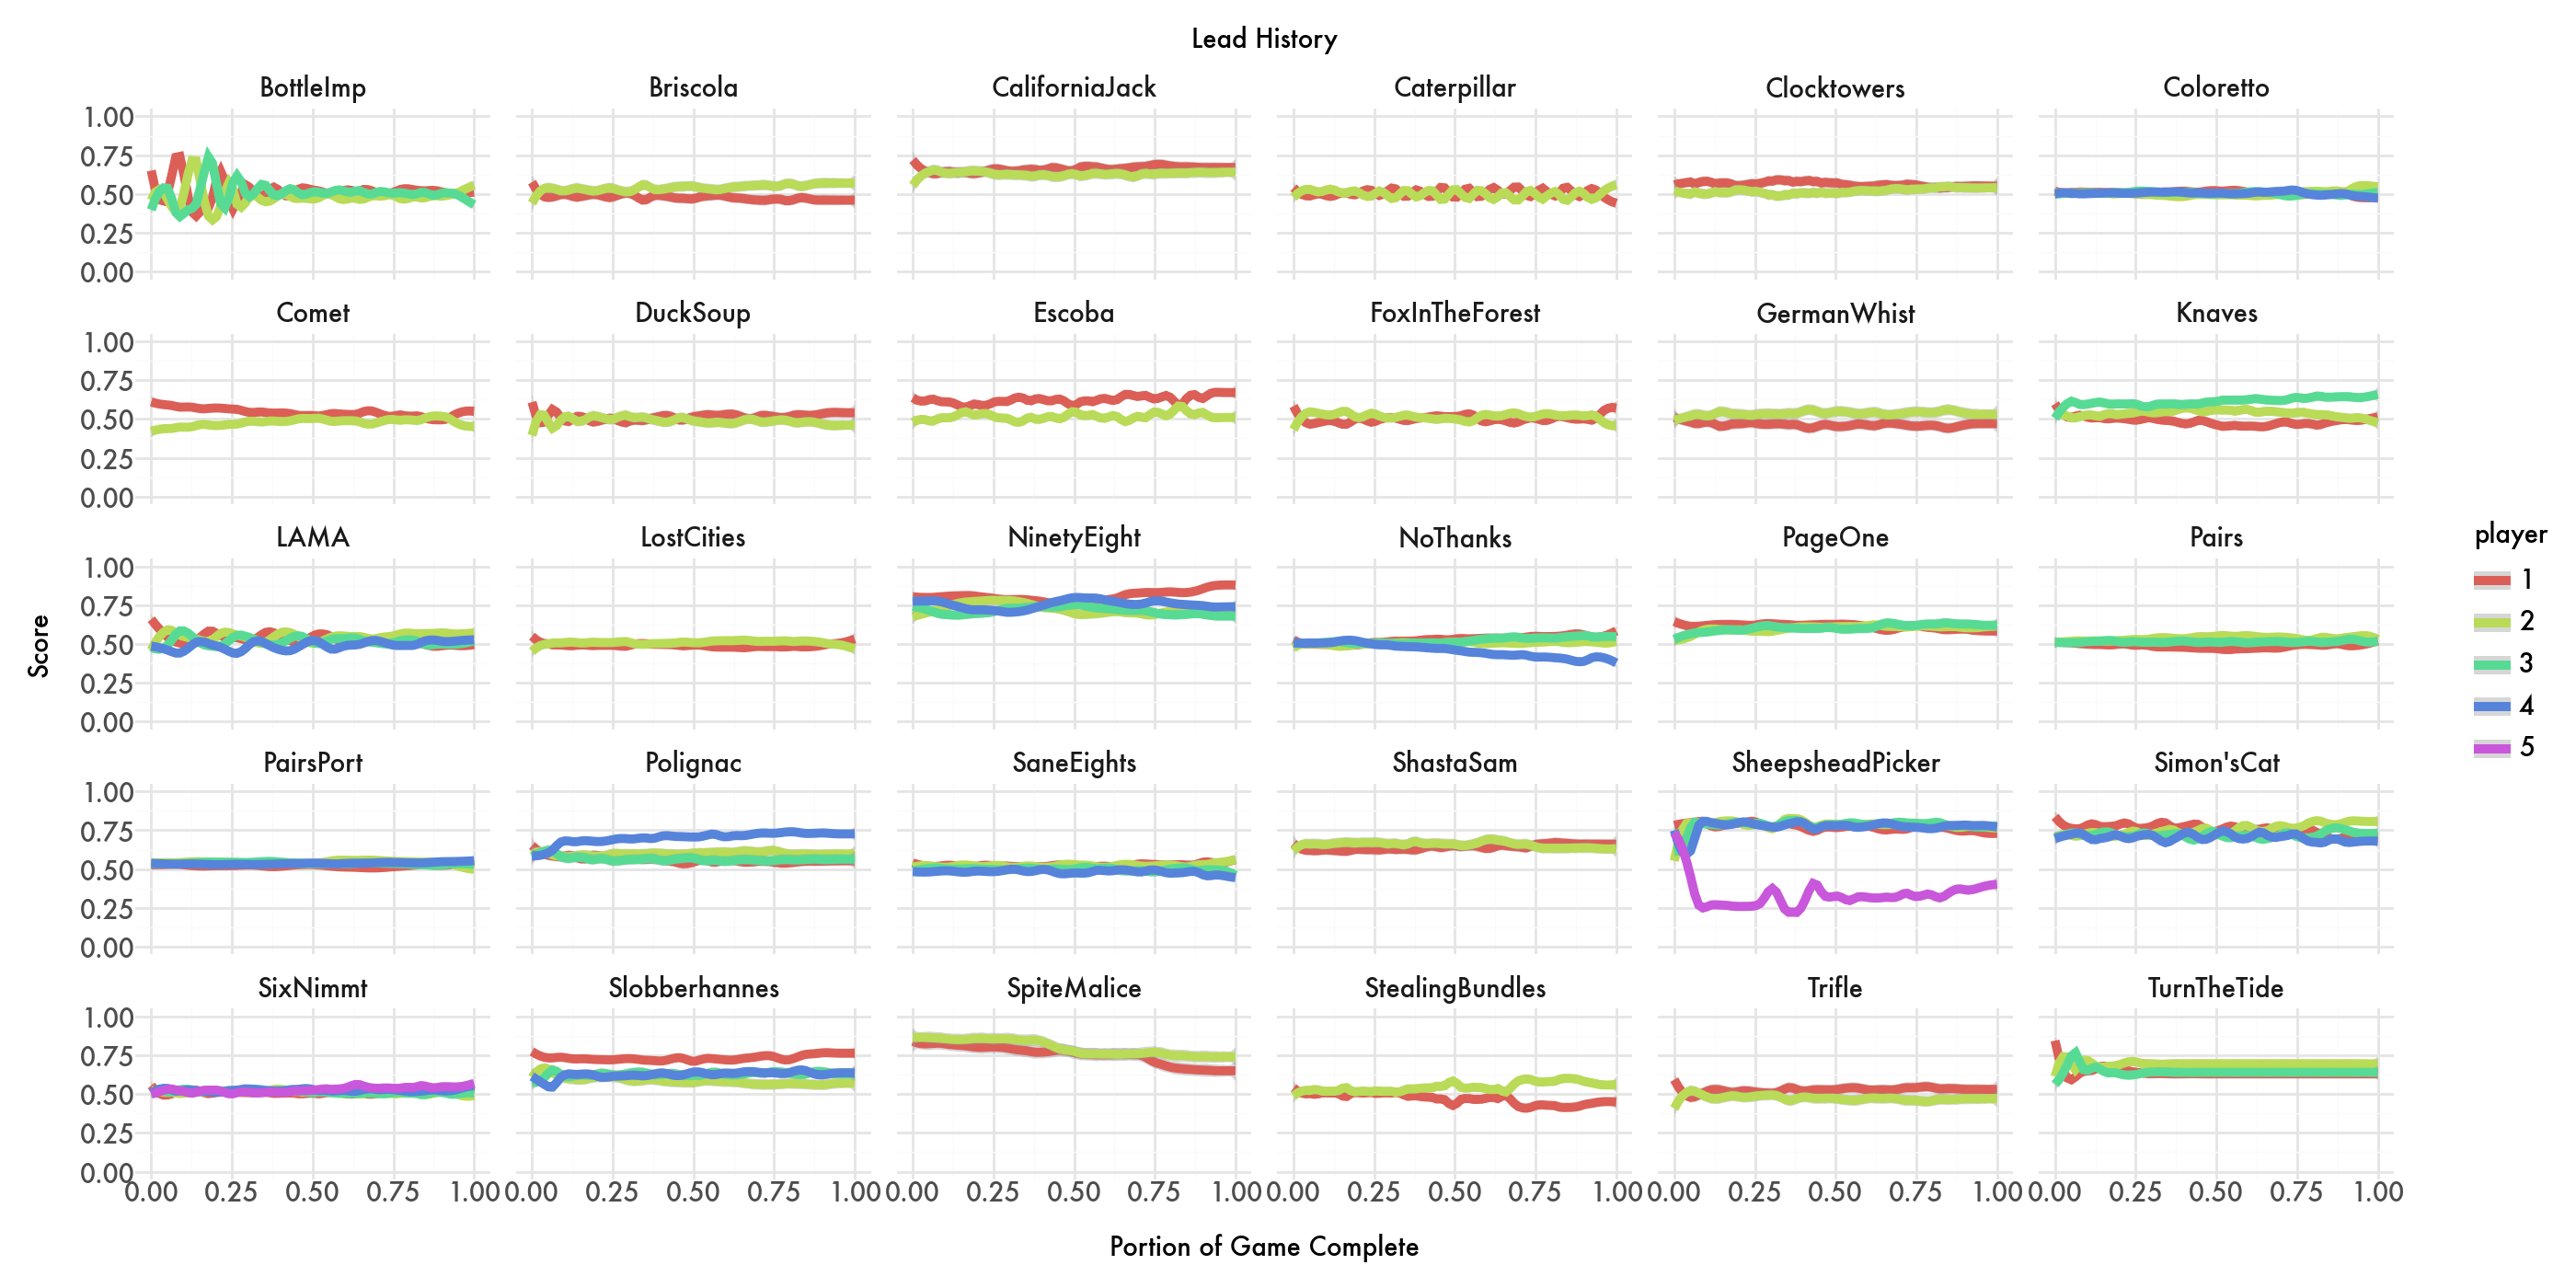

In [17]:
(ggplot(leads, aes(x="portion", y="estimate", color="player"))
    + geom_smooth(method="loess", size=2, span=0.1)
    + ylim(0, 1)
    + facet_wrap("game")
    + theme_minimal(base_family="Futura", base_size=10)
    + theme(figure_size=(14, 7), text=element_text(size=10))
    + labs(x='Portion of Game Complete', y='Score', title="Lead History")
)